In [1]:
import sys, os, pickle, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, mannwhitneyu, kruskal, fisher_exact
from statsmodels.stats.multitest import multipletests

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from spk_lfp_cluster_comp_analysis import *
from spk_feat_cluster_comp_analysis import compile_experiment_results
from config import SPE1_PICKLE_ROOT, PRIORITY_CELLS, CELL_IDS, DICT_CELL_TYPE, DICT_PATCH_TYPE, DICT_CORT_DEPTH, DICT_DARK_NEURONS, DICT_EAP_WAV

warnings.filterwarnings("ignore")

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
SLIDING_DIR  = os.path.join(SPE1_PICKLE_ROOT, "lfp_spk_group_pickles")
PREPOST_DIR  = os.path.join(SPE1_PICKLE_ROOT, "prepost_specparam_pickles")
CLUSTER_DIR  = os.path.join(SPE1_PICKLE_ROOT, "cluster_pickles")

# ── Cell subsets ───────────────────────────────────────────────────────────────
subsets = get_cell_subsets(PRIORITY_CELLS, CELL_IDS)
SUBSET_LABELS = [
    ("Priority cells",      subsets["priority"]),
    ("Non-priority cells",  subsets["np"]),
    ("All cells combined",  subsets["all"]),
]
print(f"Priority: {len(subsets['priority'])} | NP: {len(subsets['np'])} | All: {len(subsets['all'])}")

# ── Feature type definitions ───────────────────────────────────────────────────
# Numerical LFP features (effect sizes, continuous)
LFP_NUMERICAL = ["exponent", "r_squared", "band_aucs.theta",
                  "band_aucs.gamma", "lfp_mean"]
# Dropped as redundant: offset (collinear w/ exponent), lfp_std, lfp_exponent

# Spike feature colours
feature_shades = {
    'peak_amp_cluster':         '#8c564b',
    'peak_sharpness_cluster':   '#a06d62',
    'peak_width_cluster':       '#b38479',
    'exp_lambda_cluster':       '#c561a8',
    'inflection_time_cluster':  '#9b59b6',
    'exp_const_cluster':        '#d7aee0',
    'log_isi_cluster':          '#7f7f7f',
    'spk_times_ms_cluster':     '#b0b0b0',
}

# Module-level constants (not exported by import *)
_CB_PALETTE = ['#0072B2', '#D55E00', '#009E73', '#CC79A7',
               '#56B4E9', '#E69F00', '#F0E442', '#000000']
_SIG_COL    = '#D55E00'
_INSIG_COL  = '#56B4E9'
_FS_SM, _FS_AX, _FS_SUB, _FS_TTL = 11, 13, 14, 16


Priority: 7 | NP: 36 | All: 43


## Load data

In [3]:
df_prepost   = compile_prepost_stats(PREPOST_DIR)
df_master    = compile_experiment_results(CLUSTER_DIR)
df_spk_metrics = (df_master[["cell_id","spike_feature","nRMSE","cos_sim"]]
                  .drop_duplicates()
                  .assign(spike_feature=lambda d: d["spike_feature"].str.replace("_cluster","",regex=False)))

print(f"{df_prepost['cell_id'].nunique()} cells loaded")

36 cells loaded


## LFP feature redundancy

Which LFP features carry the same information? We check pairwise Spearman ρ between features using effect sizes from the pre window. Highly correlated pairs get dropped — we keep `exponent`, `r²`, `theta_auc`, `gamma_auc`, `lfp_mean`.

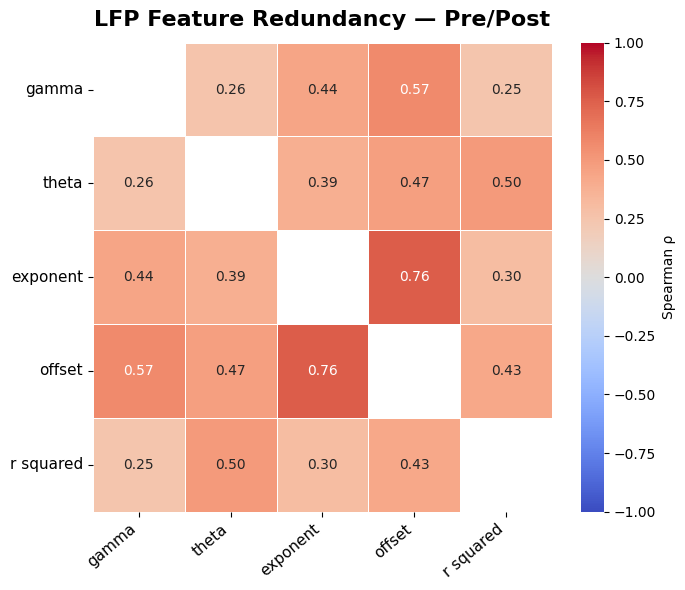

Using: ['band_aucs.gamma', 'band_aucs.theta', 'exponent', 'r_squared']


In [4]:
df_pre   = df_prepost[df_prepost["window"] == "pre"]
corr_mat = compute_lfp_feature_correlations(df_pre, effect_col="hedges_g")
plot_lfp_feature_correlation_matrix(corr_mat, "LFP Feature Redundancy — Pre/Post")

df_reduced = df_prepost[df_prepost["lfp_feature"].isin(LFP_NUMERICAL)].copy()
print(f"Using: {sorted(df_reduced['lfp_feature'].dropna().unique())}")

> Features with |ρ| > 0.7 are redundant — they tell you the same thing. If exponent and offset are tightly correlated, dropping offset is justified. Theta and gamma should be relatively independent since they capture different frequency bands.

## Effect sizes — pre, post, and within-group

How big are the LFP differences between spike clusters before and after the spike?

- **Pre window** (−0.5 to −0.05 s): was the LFP already different before the spike fired?
- **Post window** (+0.05 to +1.0 s): does the LFP diverge after the spike?
- **Within-group** (Cohen's d_z): does each cluster's own LFP change from pre to post?

**Stars above groups** = population-level significance (Wilcoxon vs 0, BH-FDR corrected). **Dots** = individual cells. Positive d = high cluster has larger LFP feature value.


Priority cells (n=7)


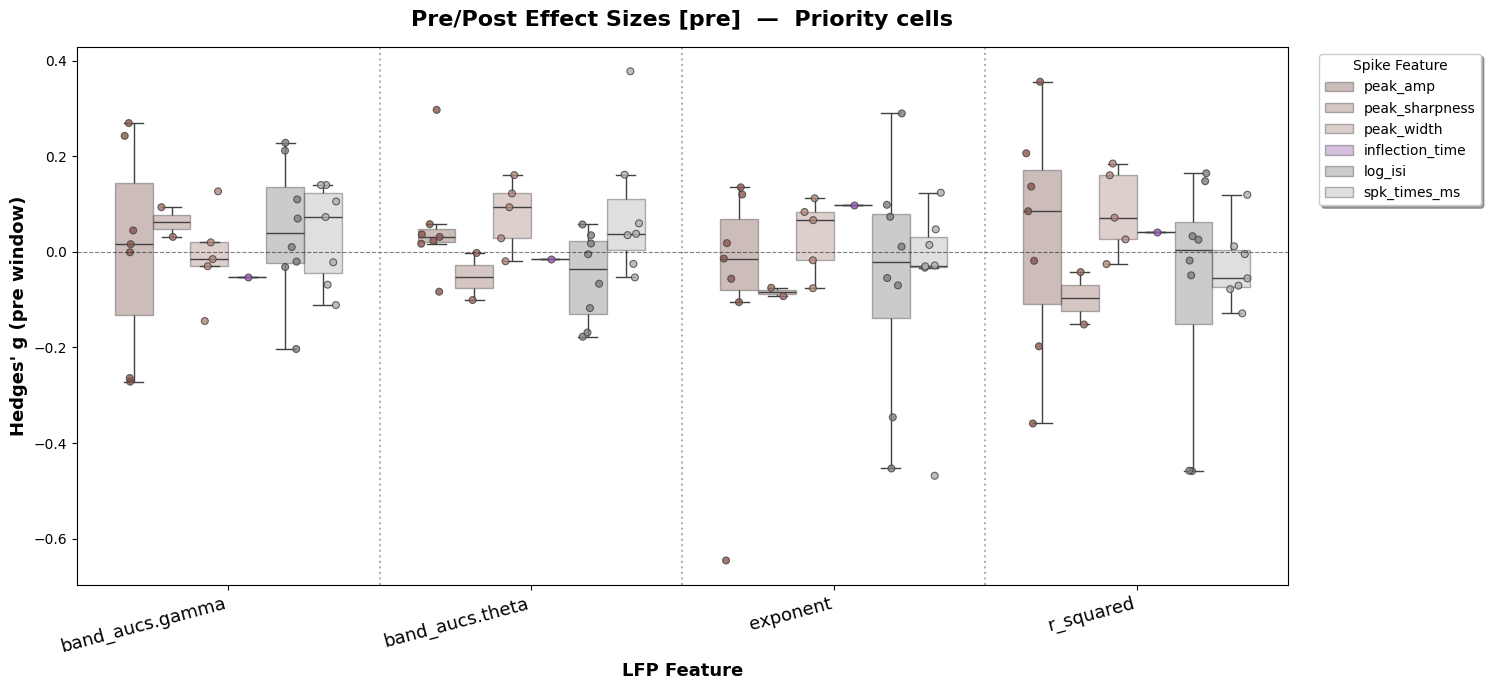

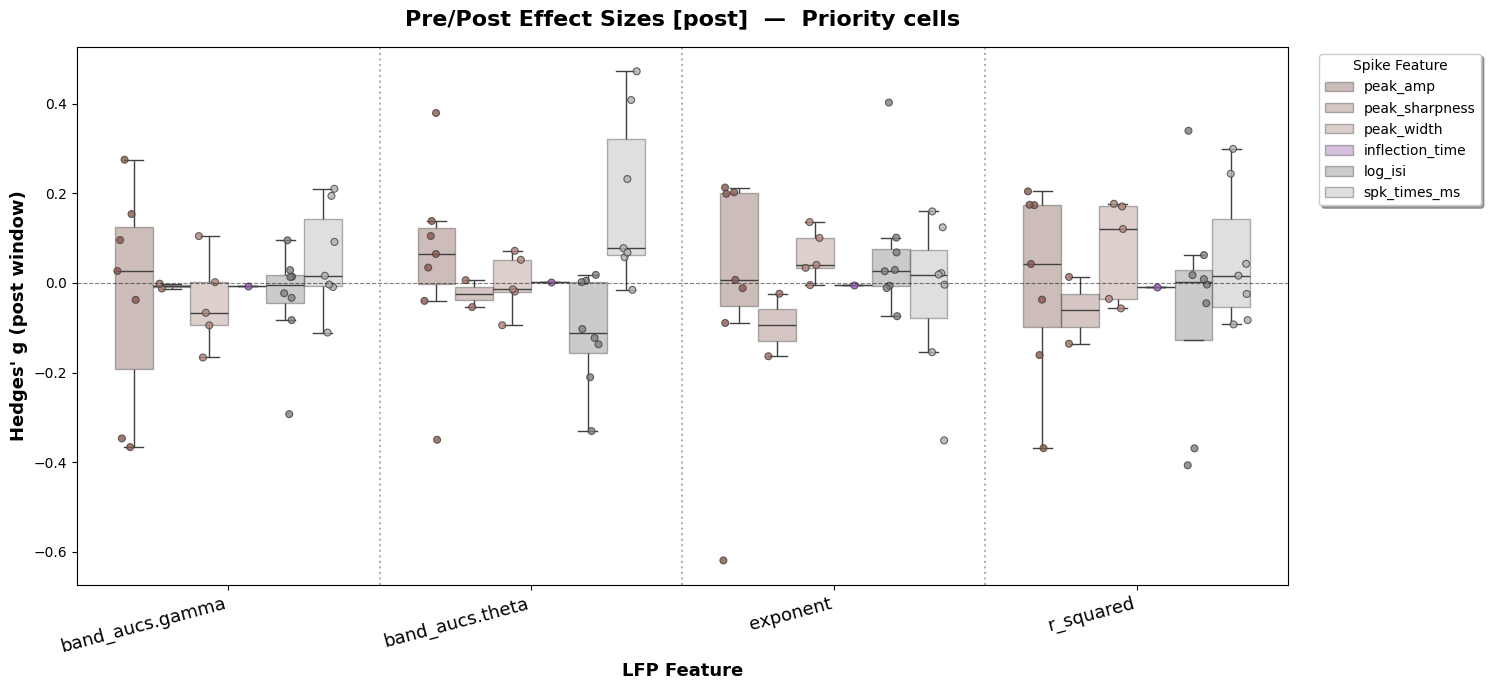

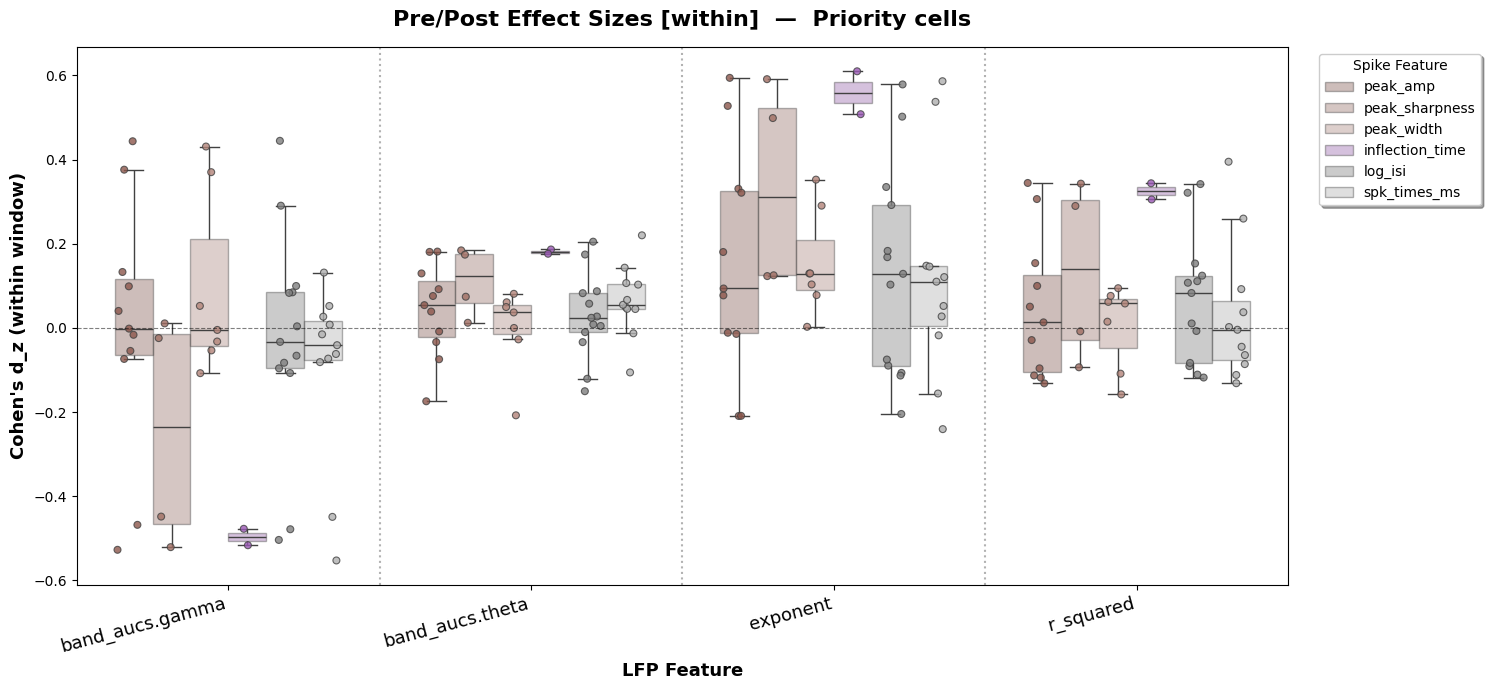

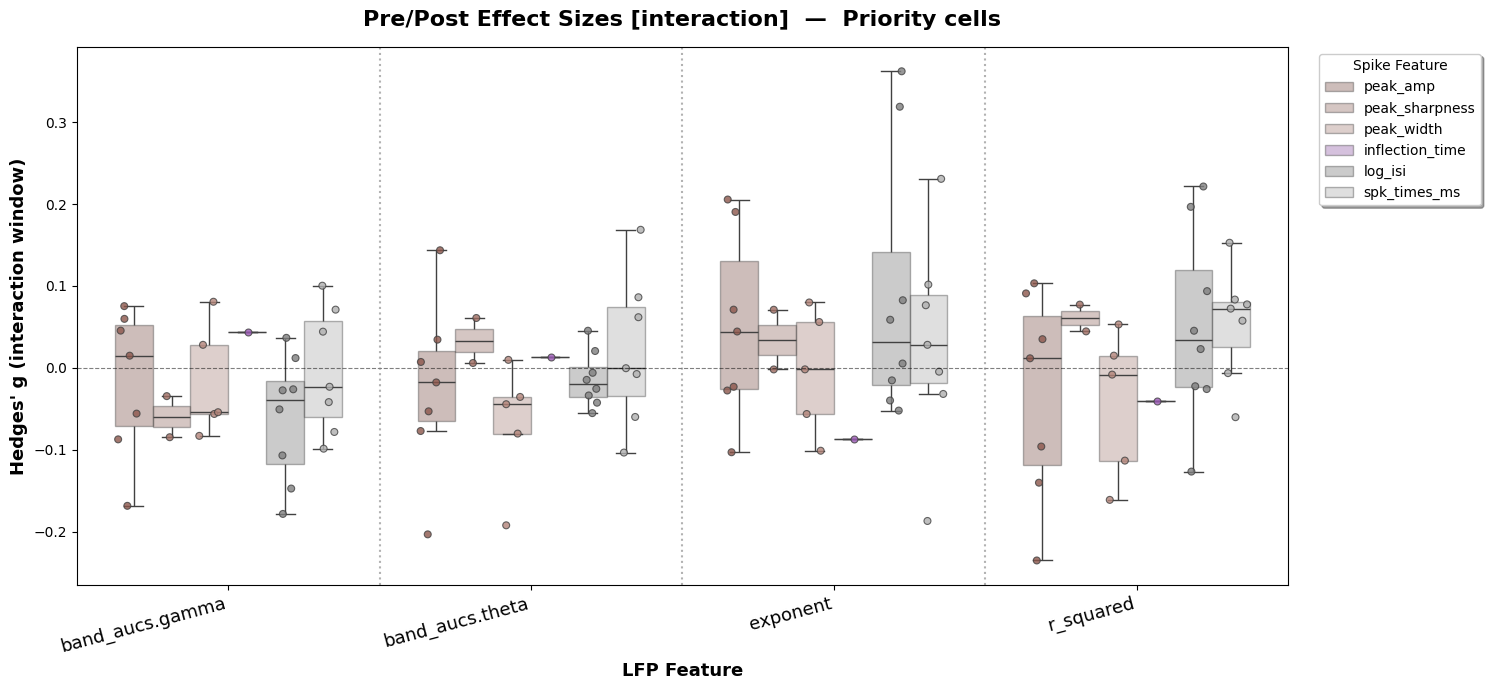


Non-priority cells (n=36)


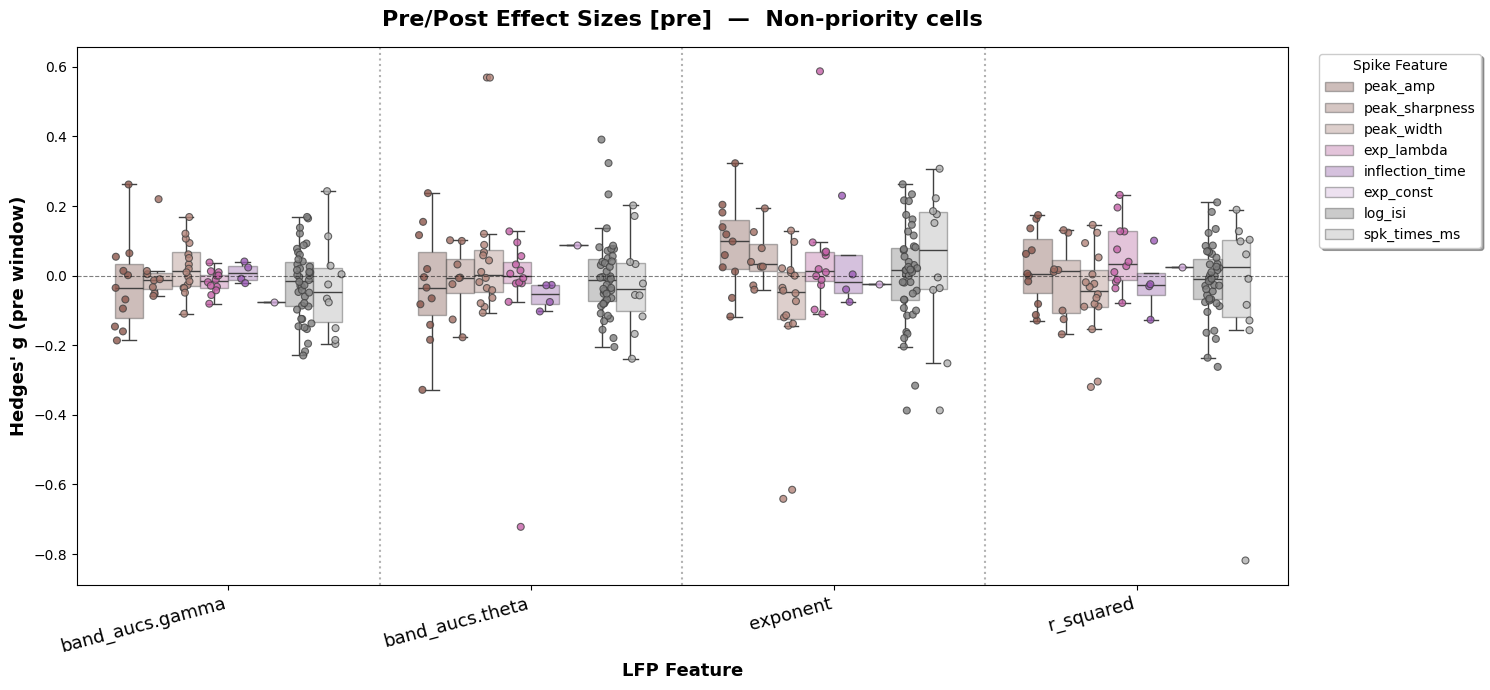

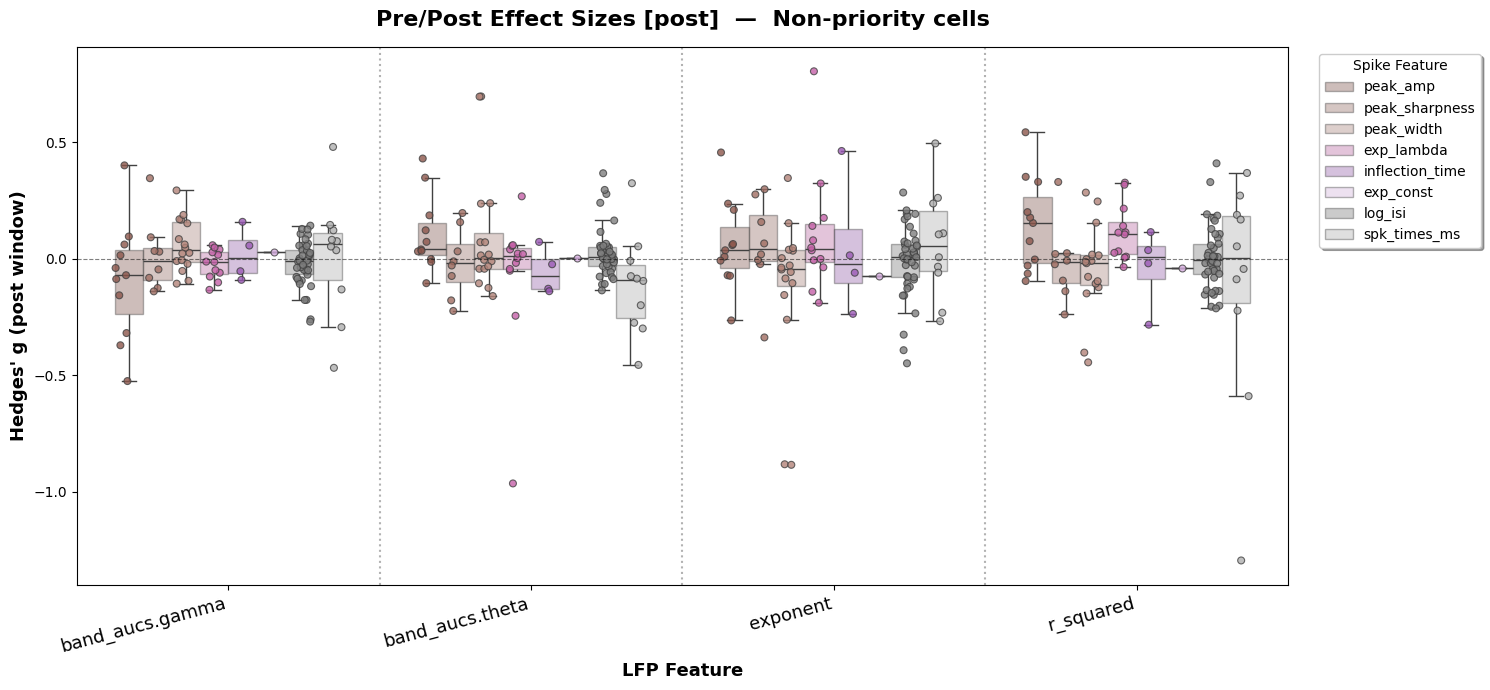

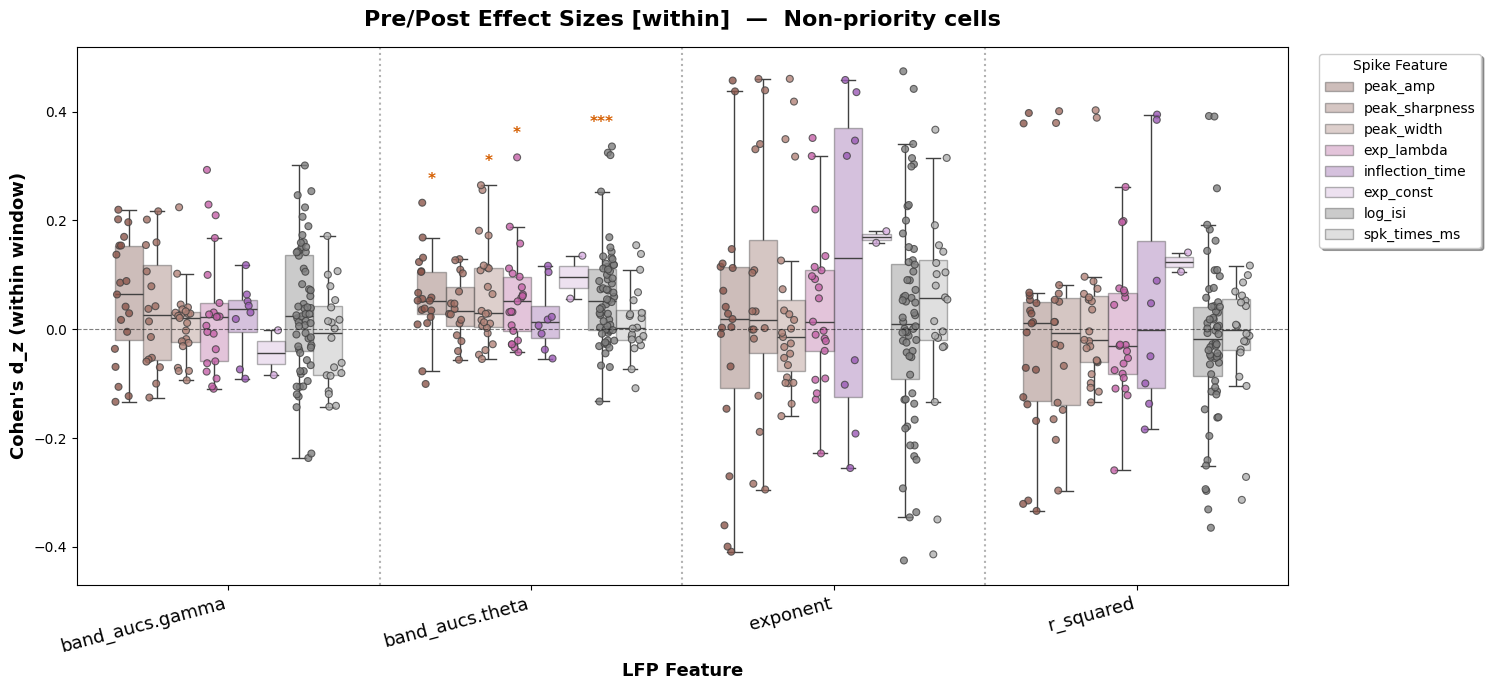

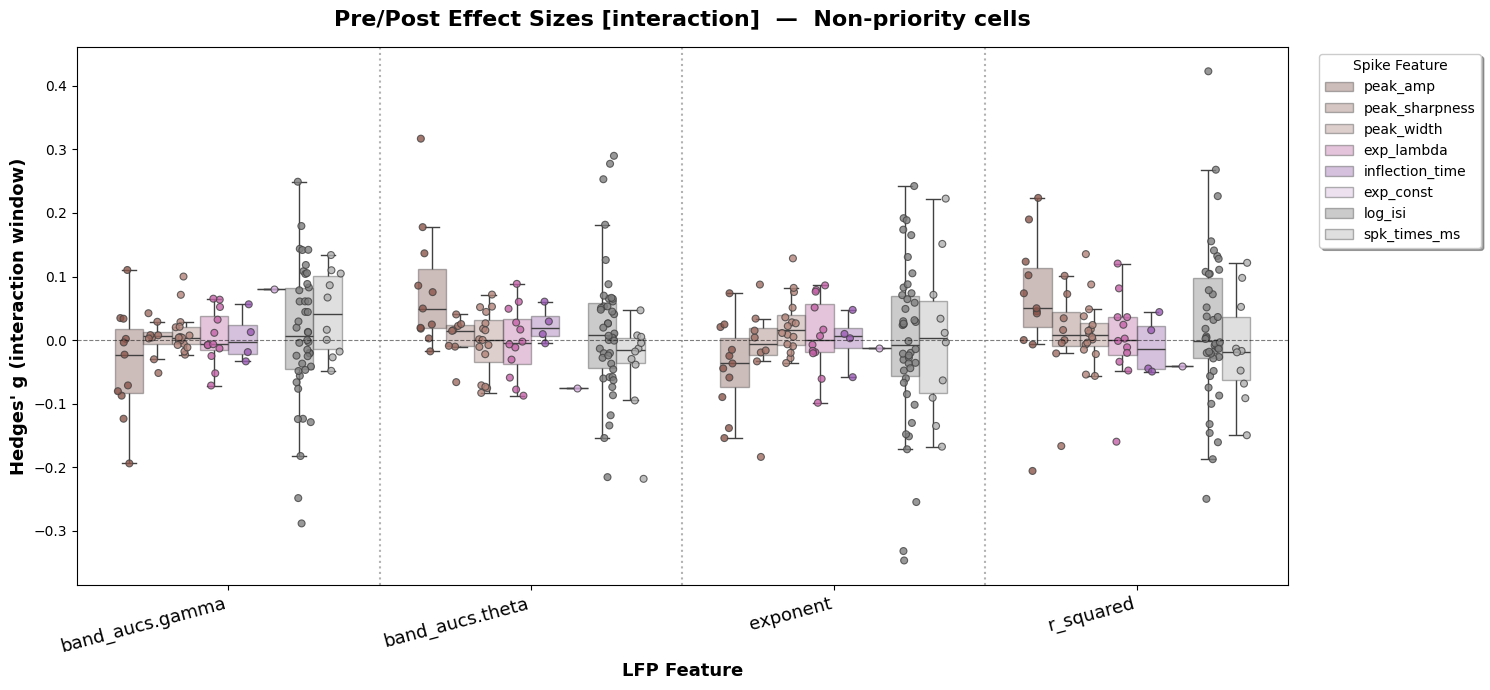


All cells combined (n=43)


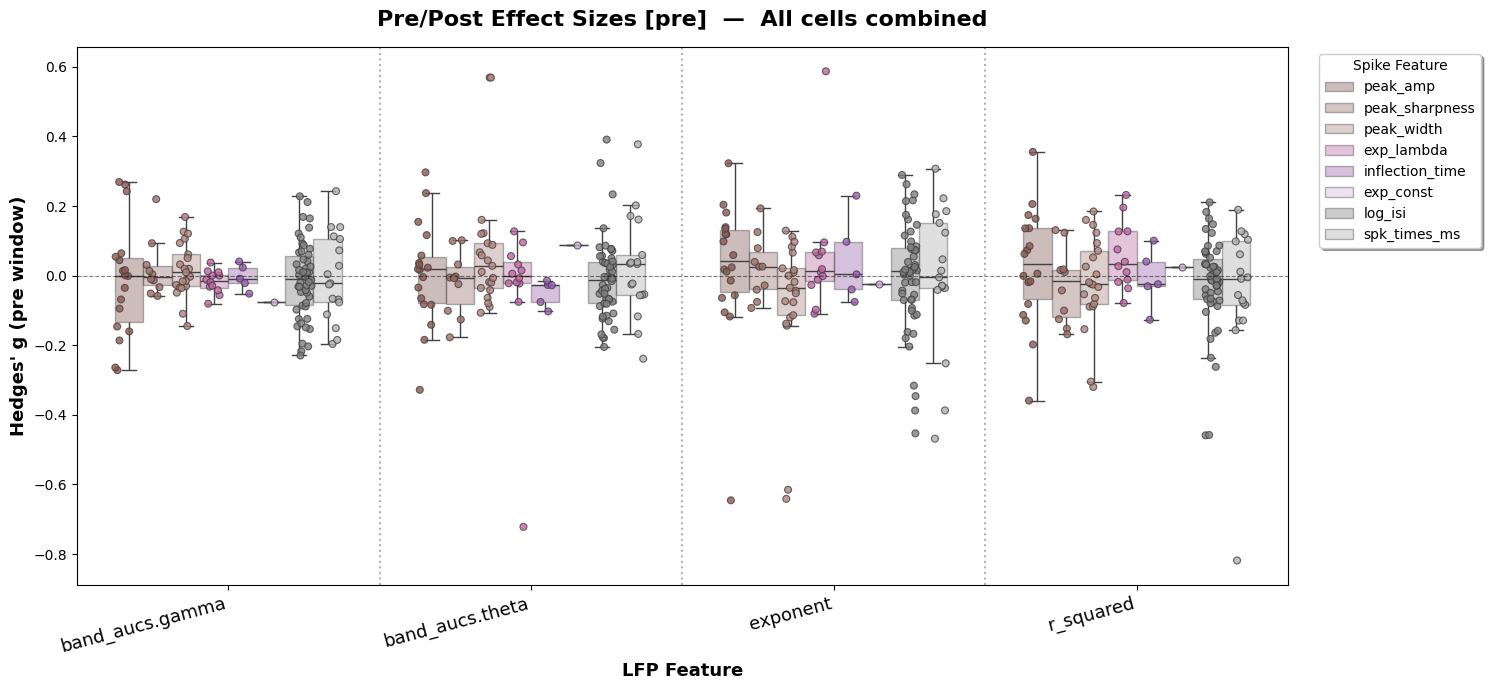

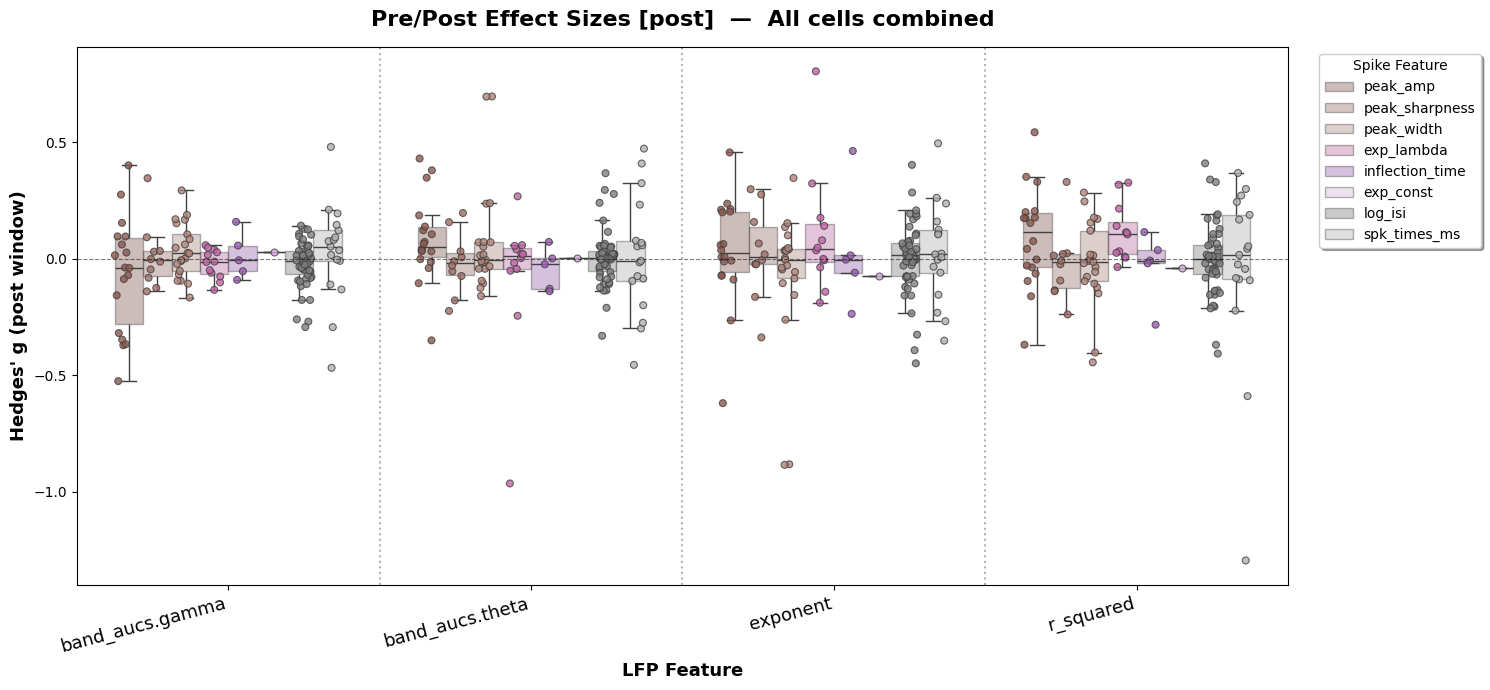

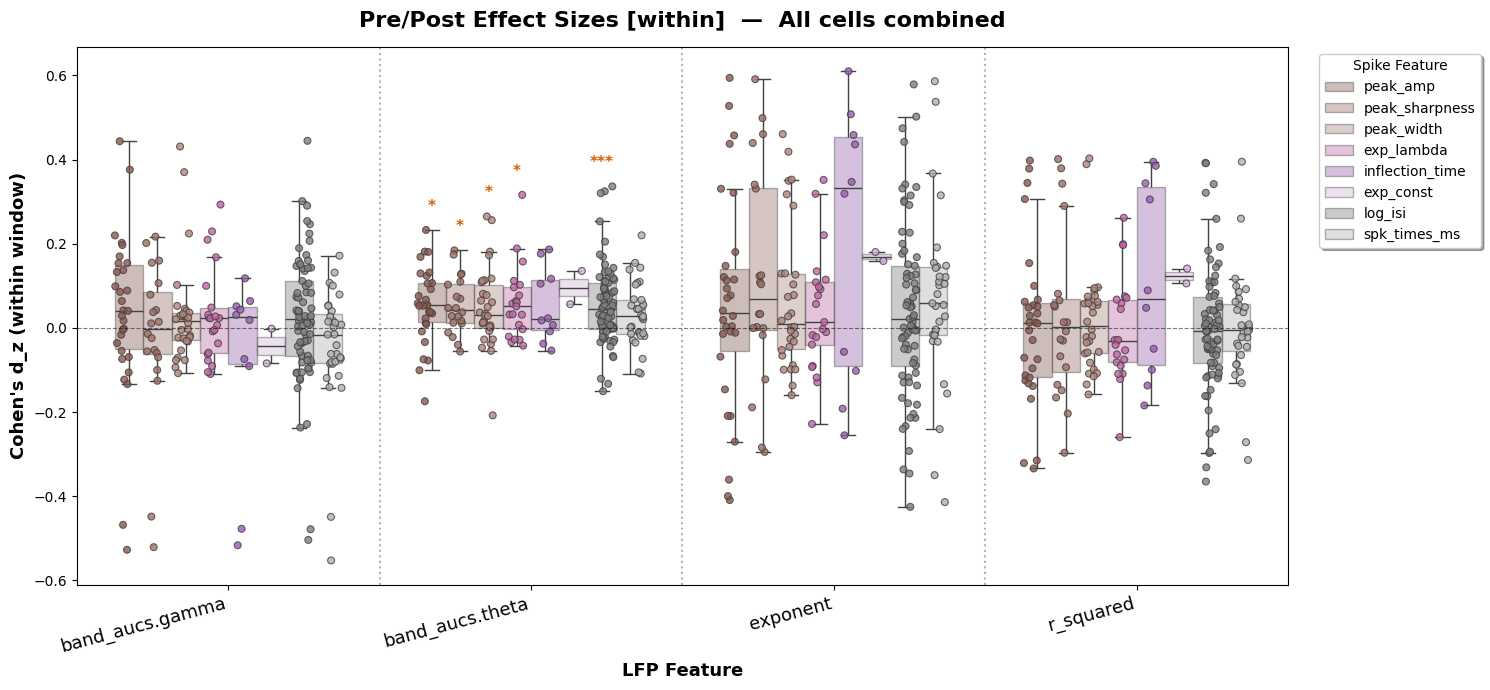

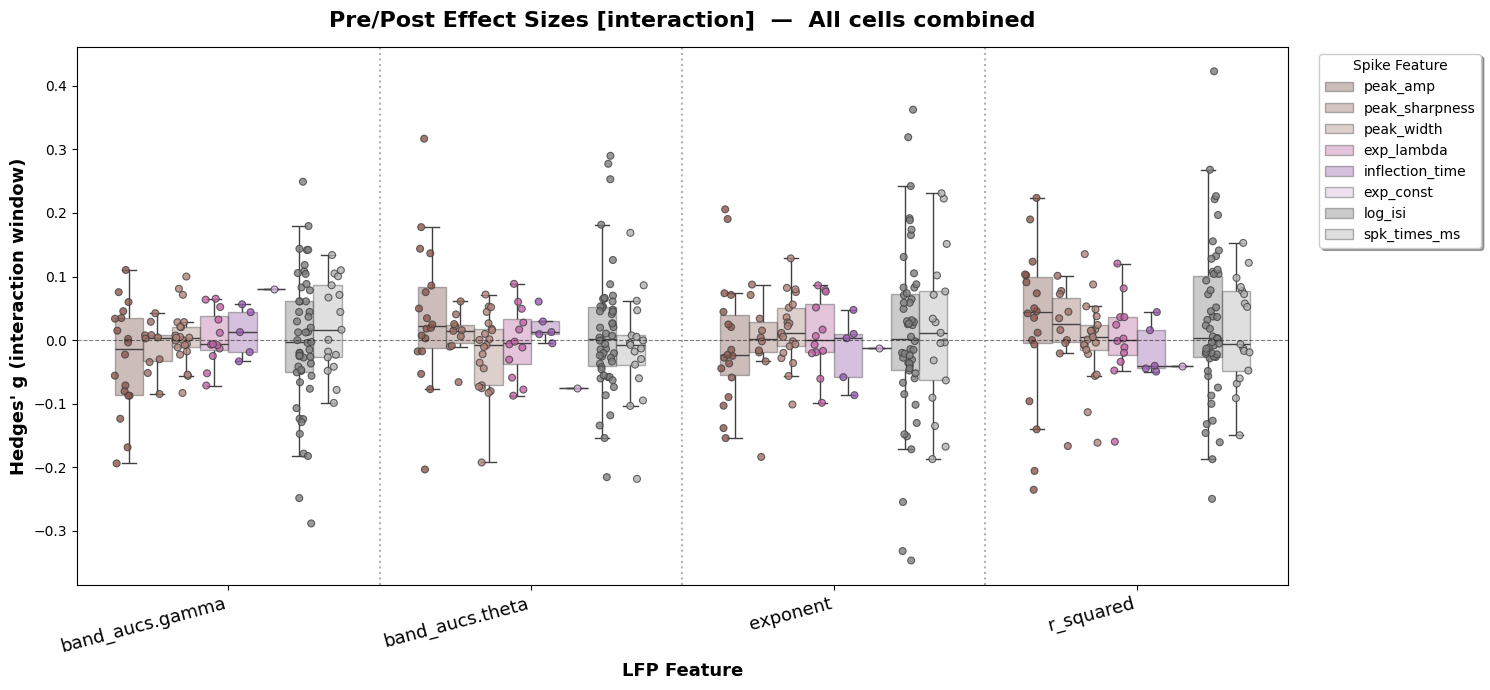

In [5]:
for label, cell_ids in SUBSET_LABELS:
    print(f"\n{'='*60}\n{label} (n={len(cell_ids)})\n{'='*60}")
    df_sub = df_reduced[df_reduced["cell_id"].isin(cell_ids)]
    plot_prepost_effect_sizes_pop(df_sub, feature_shades,
                                   lfp_features=LFP_NUMERICAL, subset_label=label)

> Stars mean the effect is consistently above zero across cells — not just a few cells driving the result. Positive g in the pre window means the high-ISI (or high-amplitude) cluster spikes tend to occur when the LFP feature is already elevated. A pre effect that flips sign post-spike suggests a state transition around the spike. Large within-group d_z means the LFP changes substantially around the spike for that cluster.

## Does waveform cluster difference predict LFP modulation?

If the LFP is genuinely tied to the spike waveform, cells with bigger waveform differences between clusters (higher nRMSE, lower cos_sim) should show stronger LFP effects.

**Spearman ρ** per LFP feature, BH-FDR corrected. **Error bars** = 95% bootstrap CI on ρ (n=1000). Orange = significant, blue = not significant.


Priority cells (n=7)


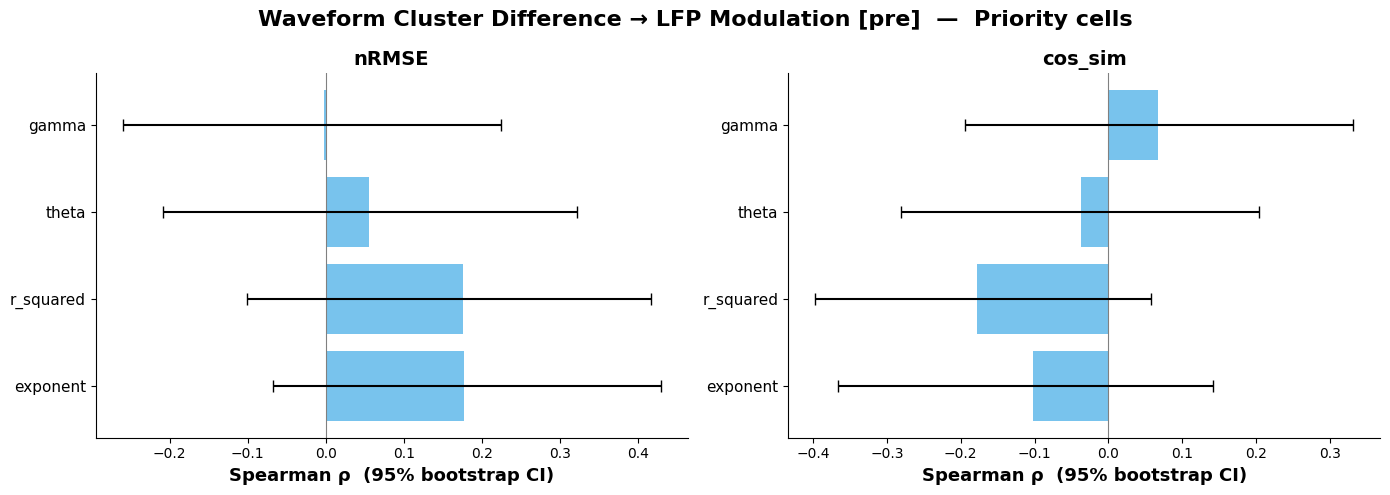

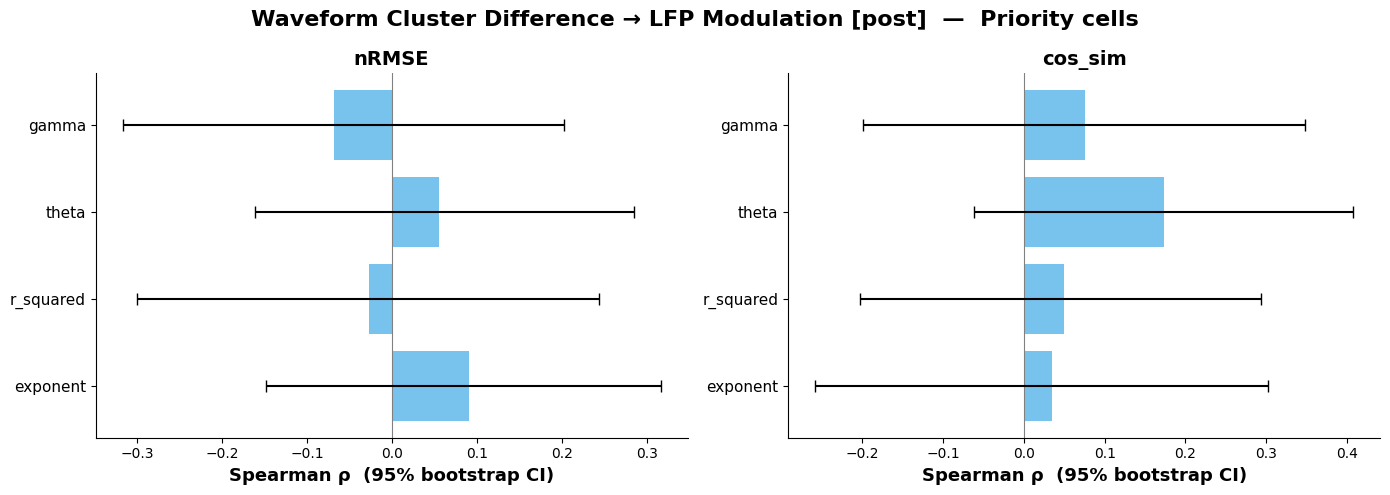

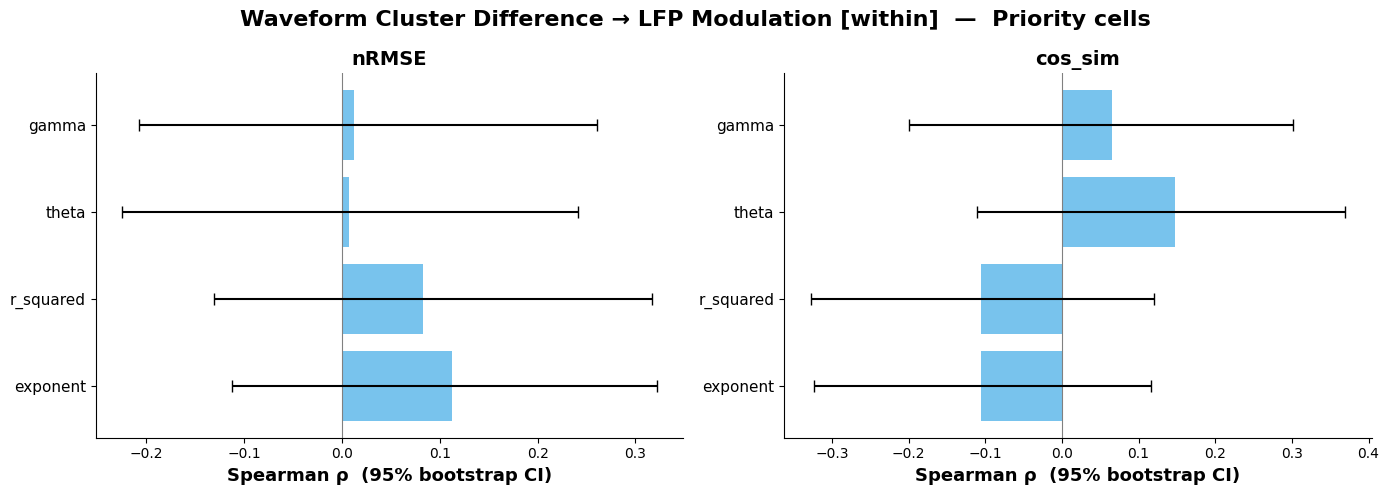

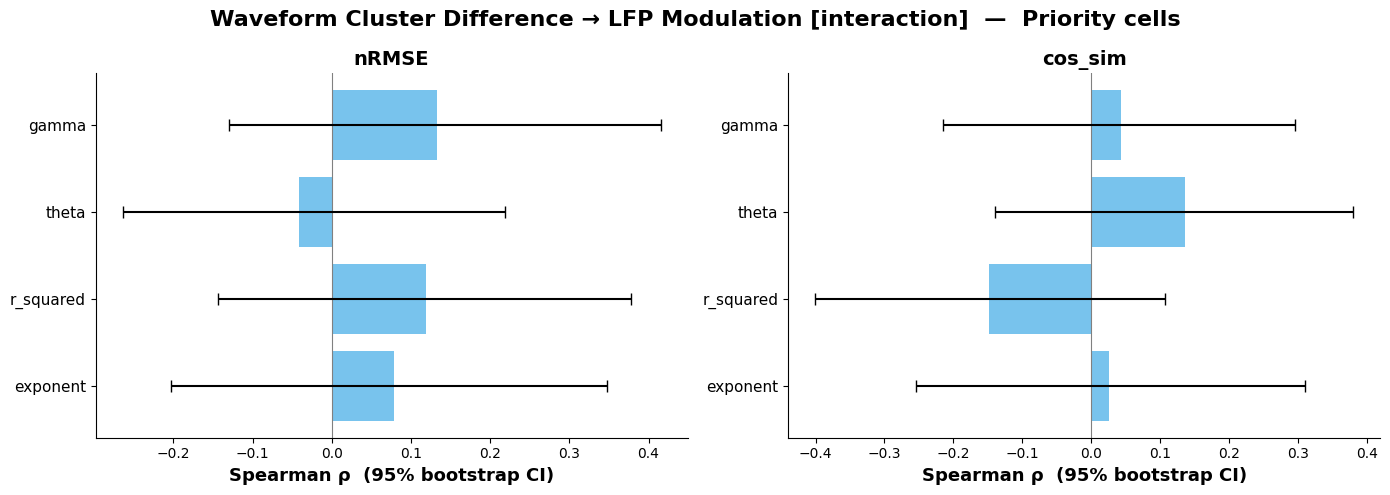


Non-priority cells (n=36)


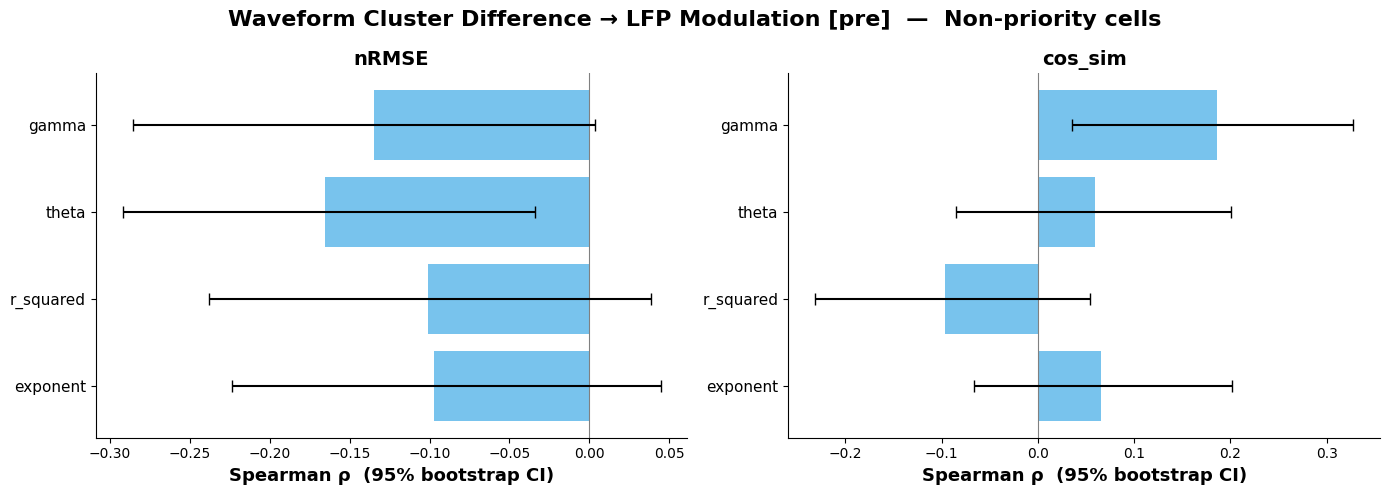

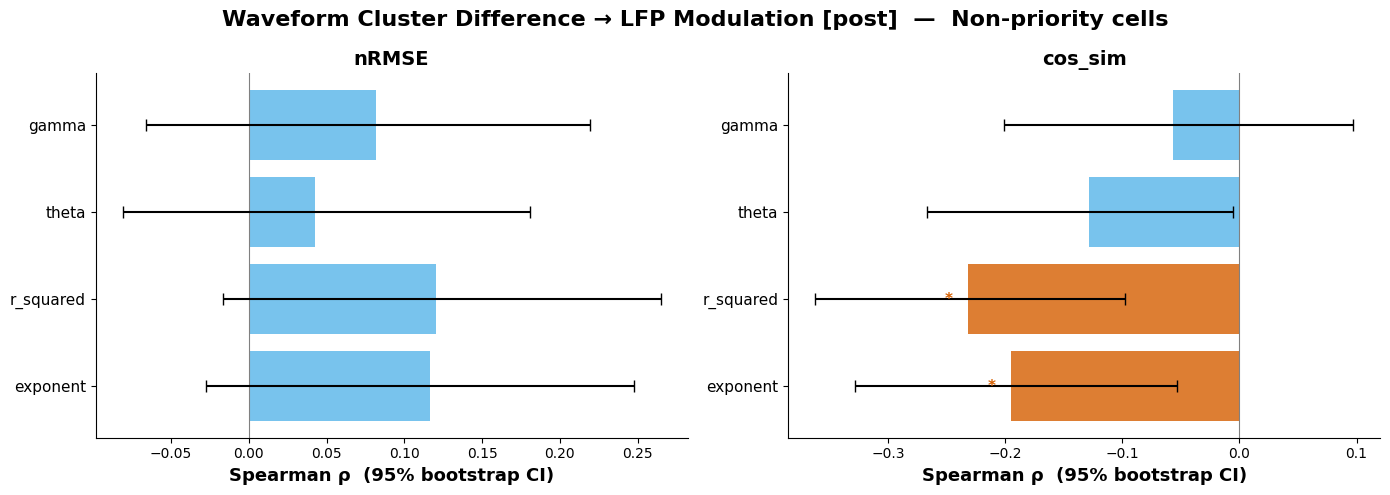

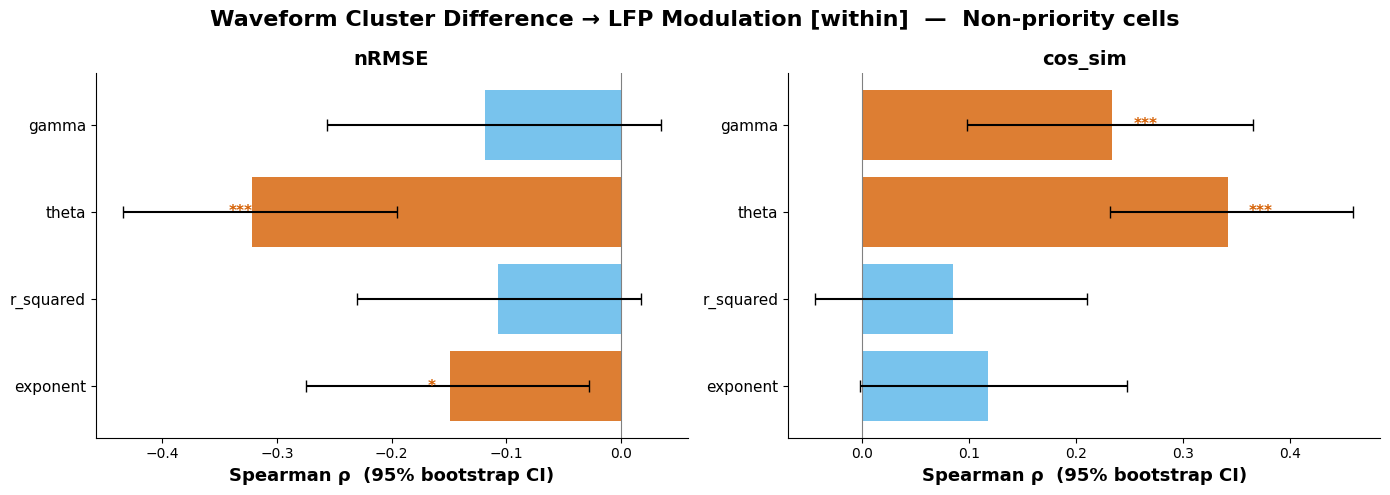

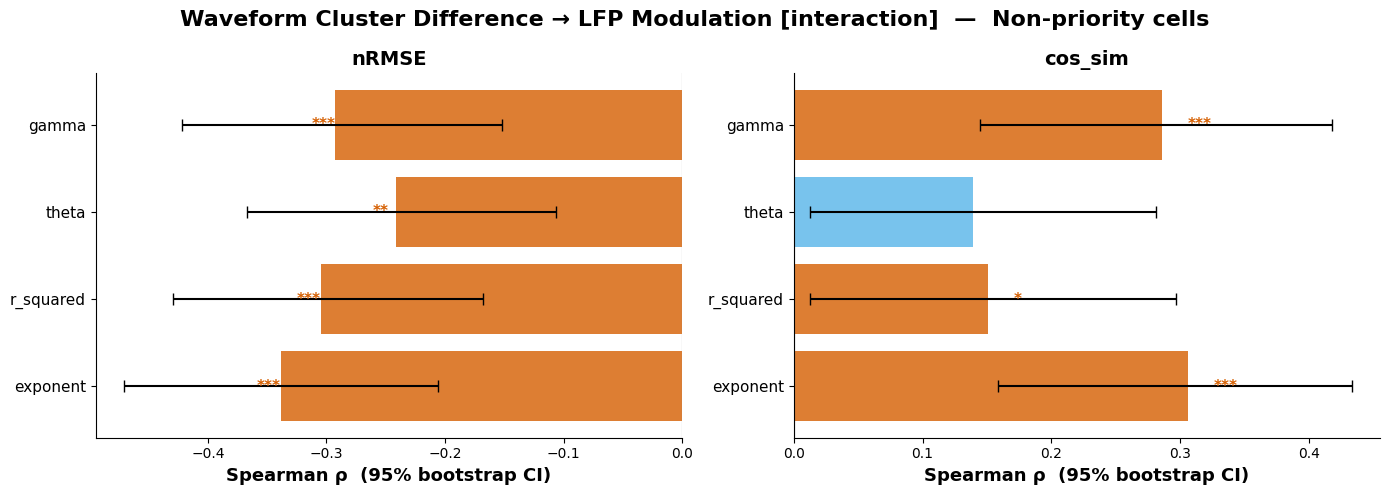


All cells combined (n=43)


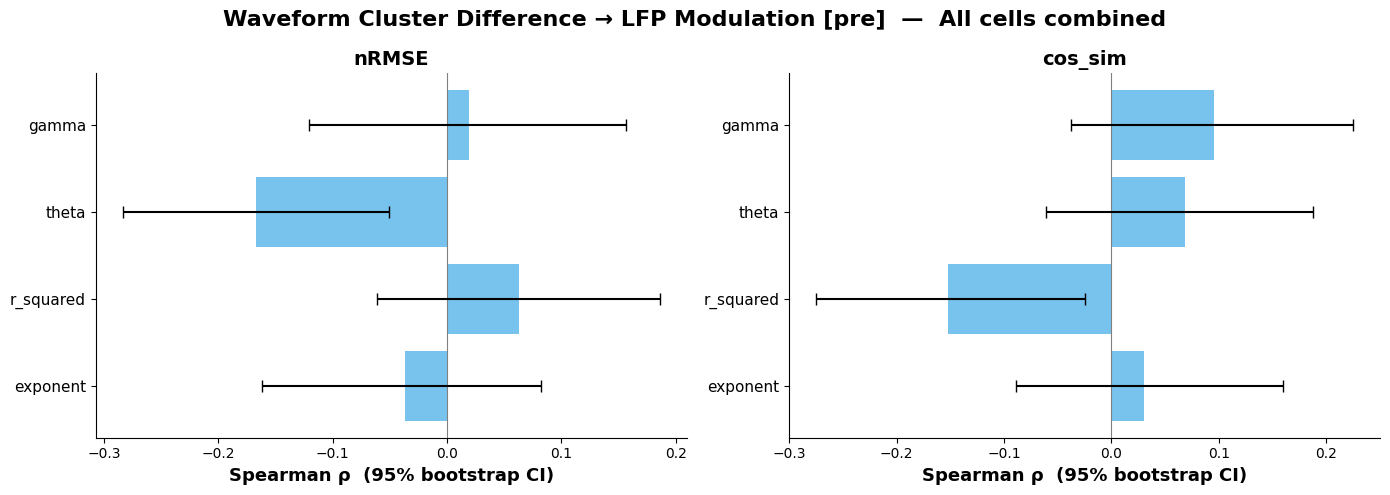

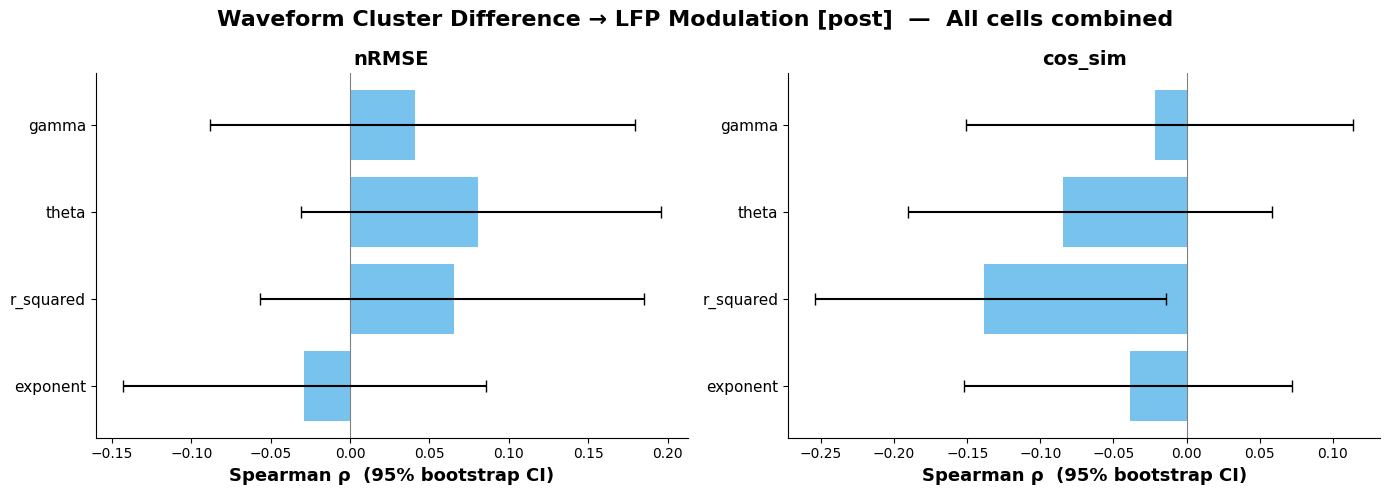

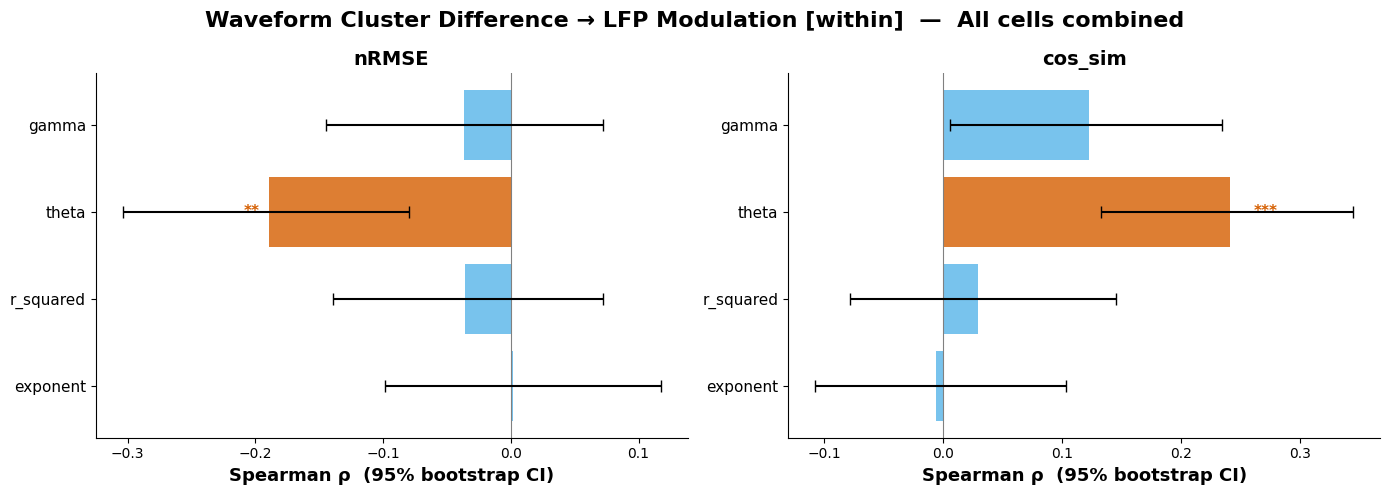

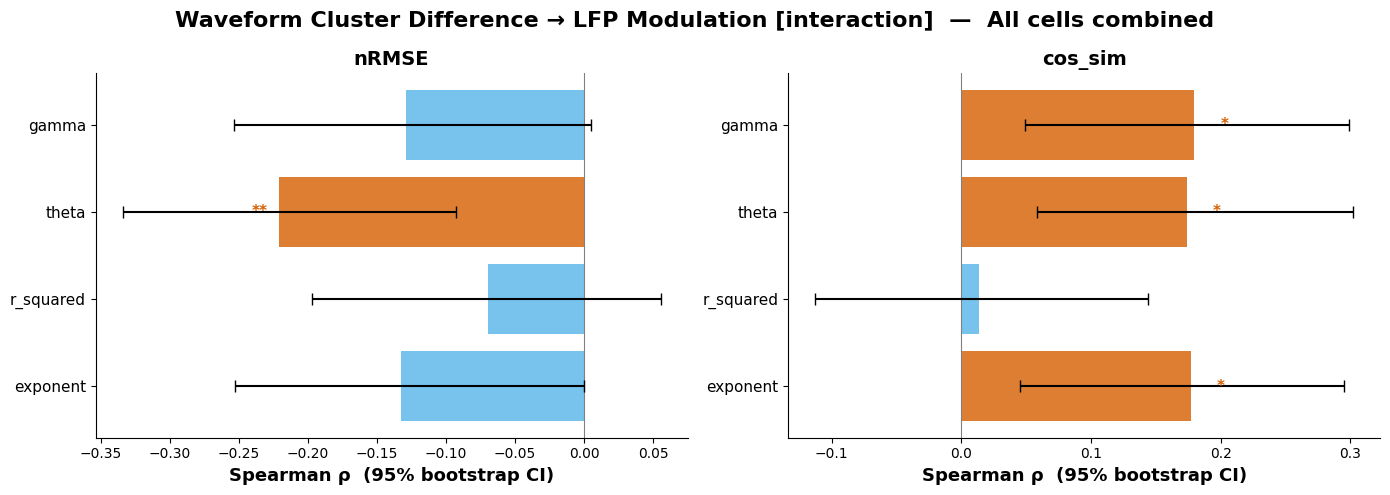

In [6]:
for label, cell_ids in SUBSET_LABELS:
    print(f"\n{'='*60}\n{label} (n={len(cell_ids)})\n{'='*60}")
    df_sub = df_reduced[df_reduced["cell_id"].isin(cell_ids)]
    plot_prepost_cluster_diff(df_sub, df_spk_metrics,
                               lfp_features=LFP_NUMERICAL, subset_label=label)

> A positive ρ for nRMSE means cells with more distinct spike clusters also show stronger LFP modulation — evidence that the LFP signal is biologically meaningful, not noise. For cos_sim, a negative ρ means the same thing (lower similarity = more different waveforms). If neither is significant, the LFP effect might be independent of how different the waveforms are.

## Interaction — does the A−B LFP difference change pre→post?

This is the main question: do spike waveform clusters have different LFP states **before** vs **after** the spike? A significant interaction means the gap between clusters changes across the spike, not just that they differ overall.


Priority cells (n=7)


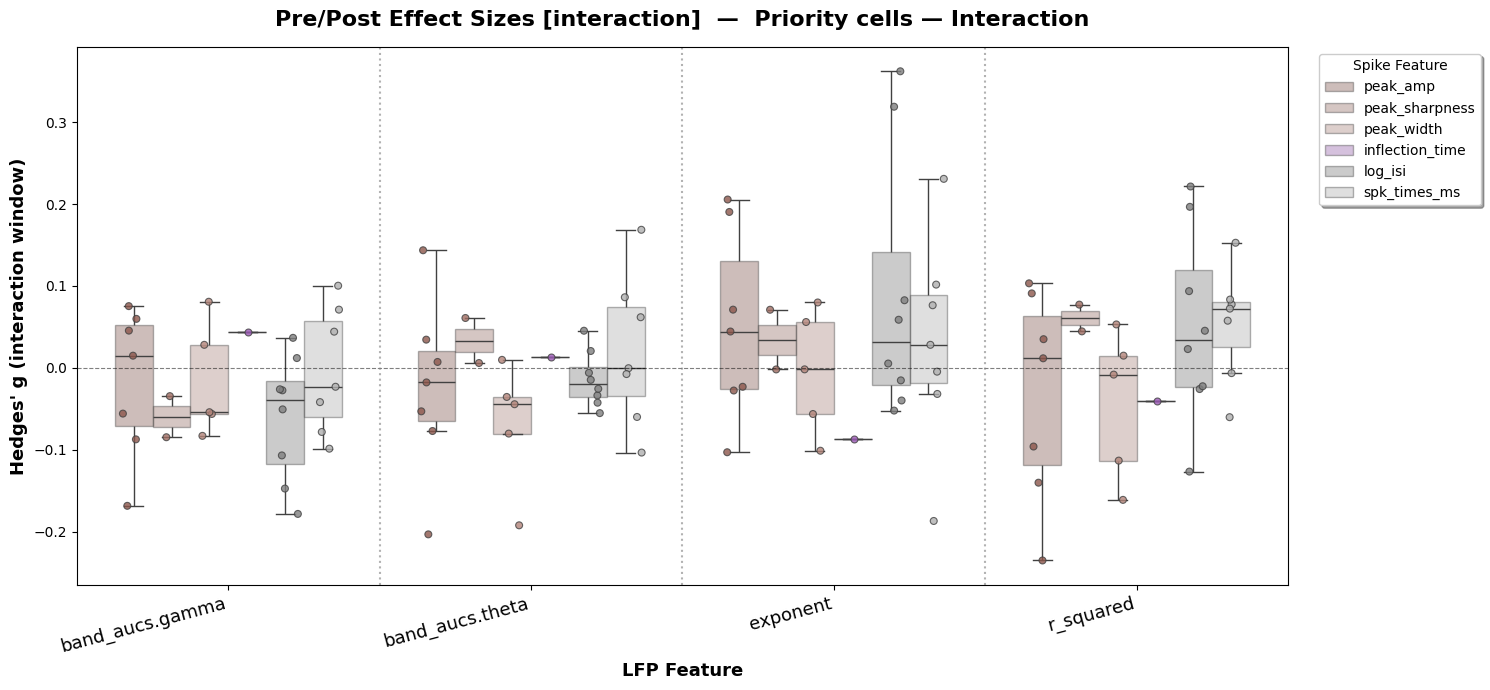


Non-priority cells (n=36)


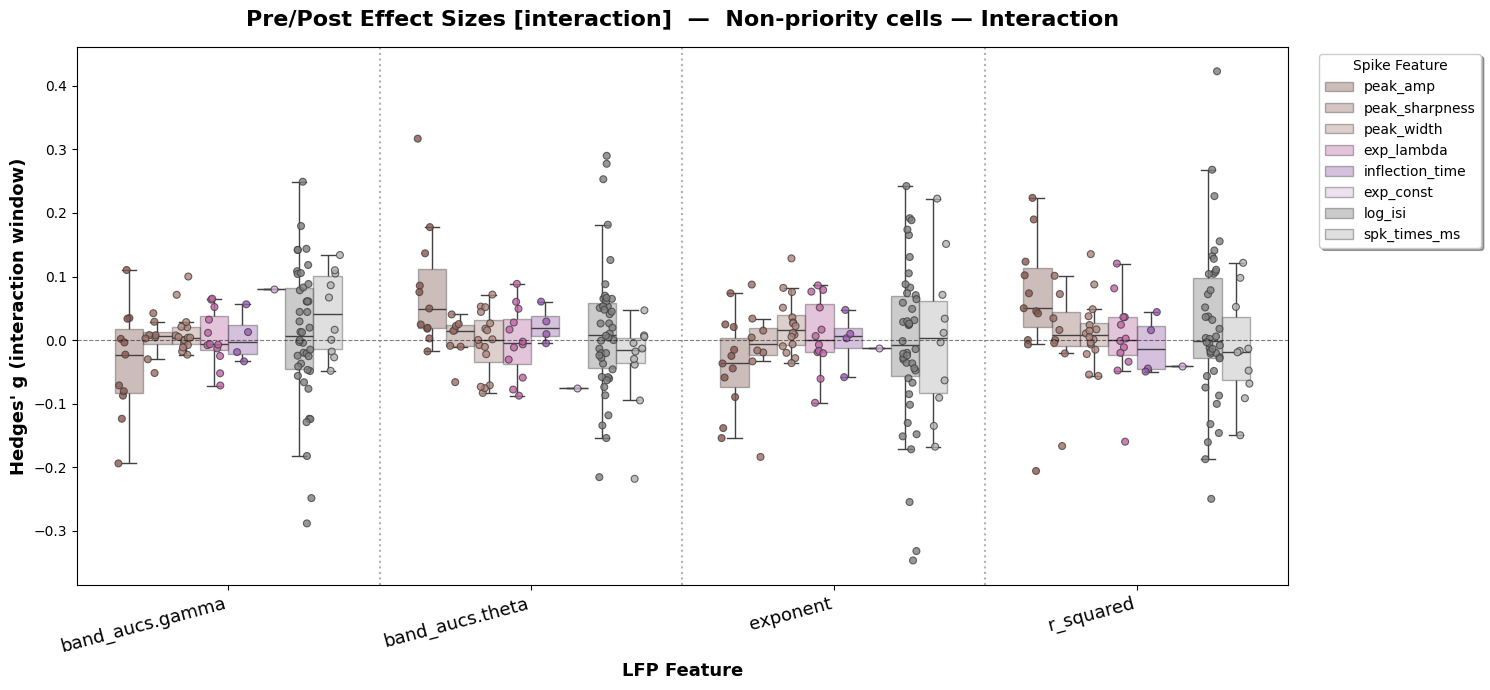


All cells combined (n=43)


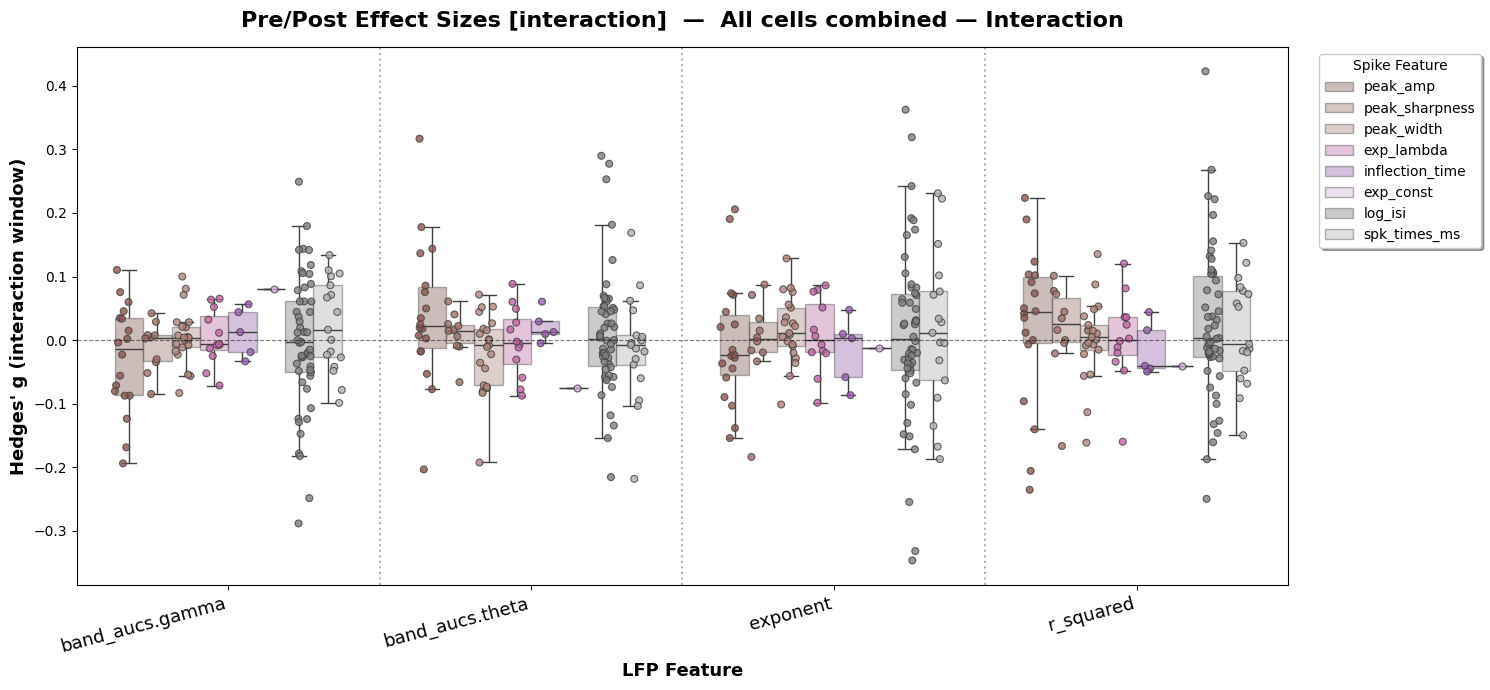

In [7]:
for label, cell_ids in SUBSET_LABELS:
    print(f"\n{'='*60}\n{label} (n={len(cell_ids)})\n{'='*60}")
    df_sub = df_reduced[(df_reduced["cell_id"].isin(cell_ids)) &
                        (df_reduced["window"] == "interaction")]
    plot_prepost_effect_sizes_pop(df_sub, feature_shades,
                                   lfp_features=LFP_NUMERICAL,
                                   subset_label=f"{label} — Interaction")

> Stars here are the strongest evidence that spike waveform clusters are embedded in different LFP dynamics. A positive interaction g means the high cluster shows a bigger pre→post LFP increase than the low cluster. No interaction but separate pre/post effects = both clusters modulate the LFP similarly, they just start from different baseline states.

## Yield — how many cells show these effects?

Effect sizes tell us how big the effects are. Yield tells us how replicable they are: what fraction of cells show a significant effect (p_fdr < 0.05) for each combination?


Priority cells (n=7)


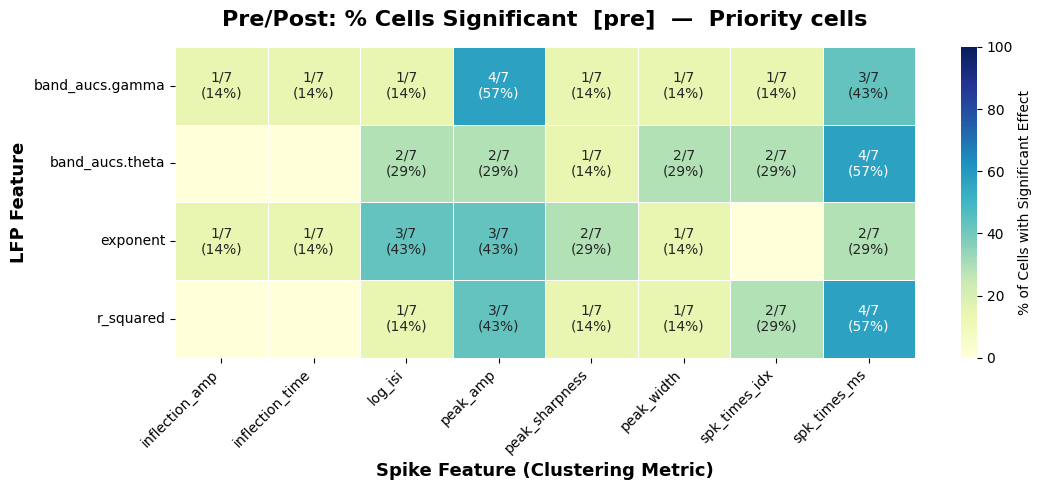

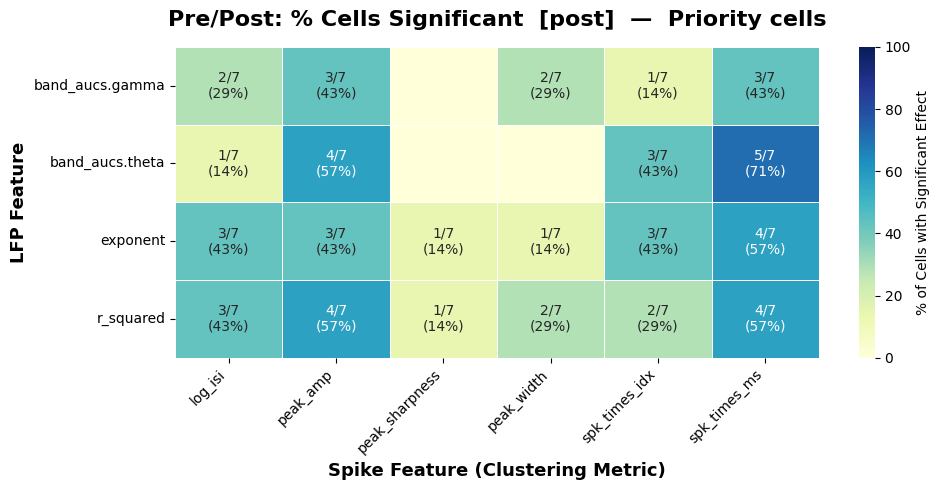

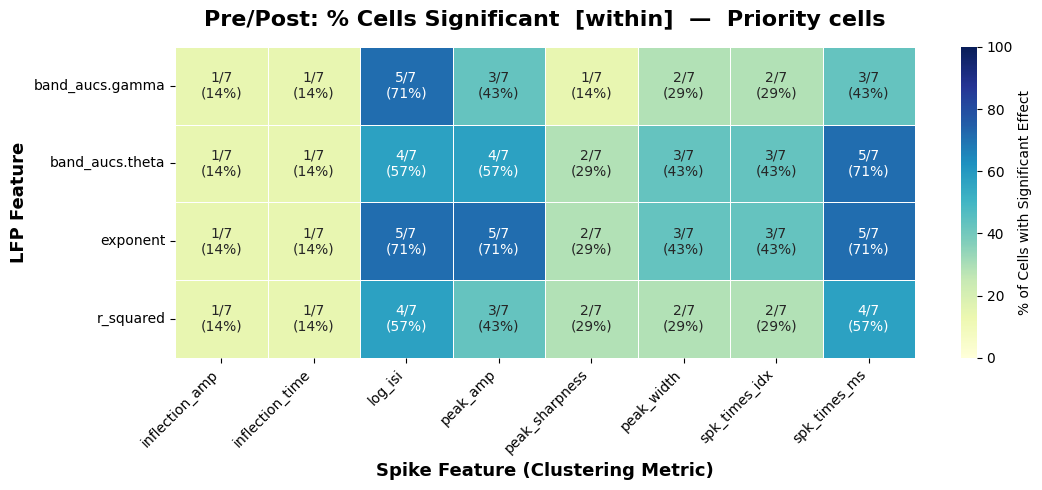

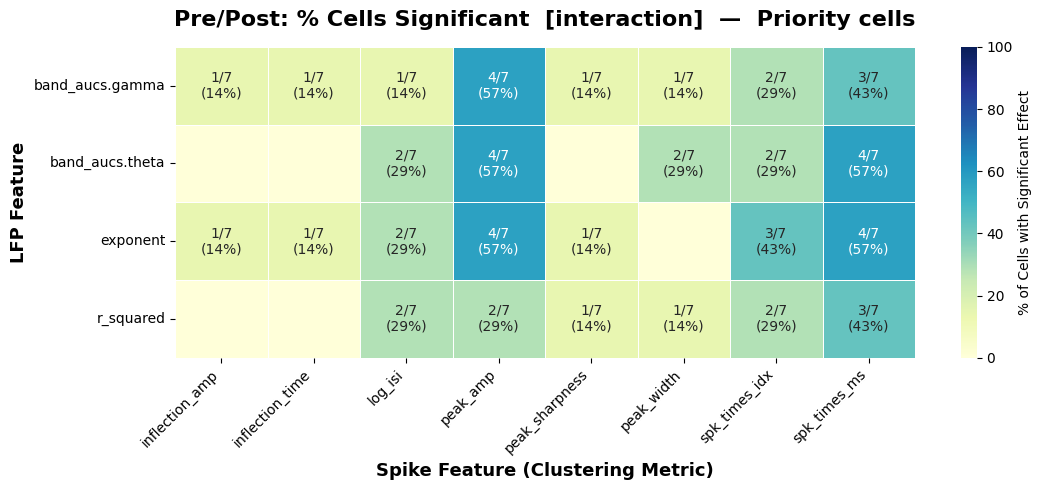


Non-priority cells (n=36)


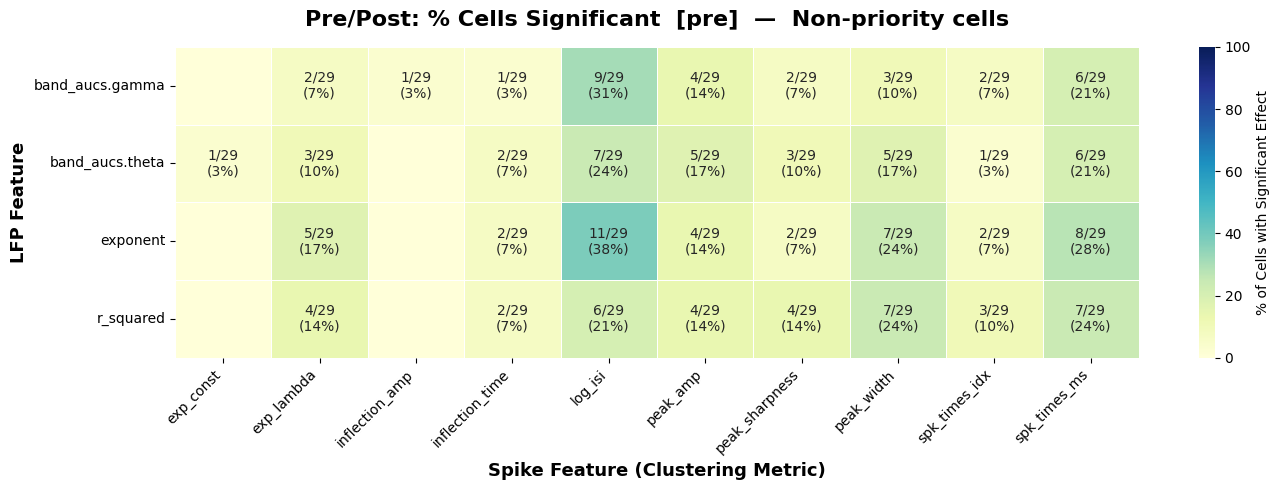

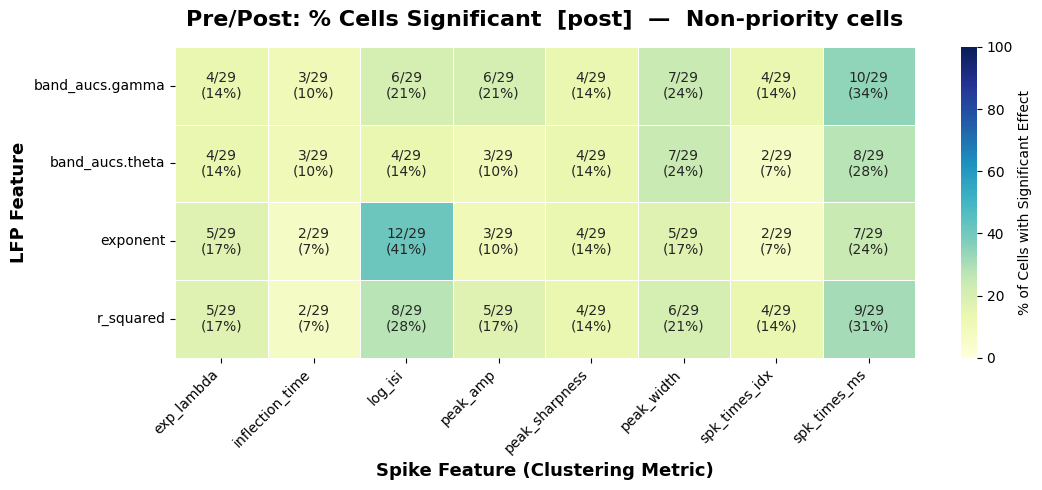

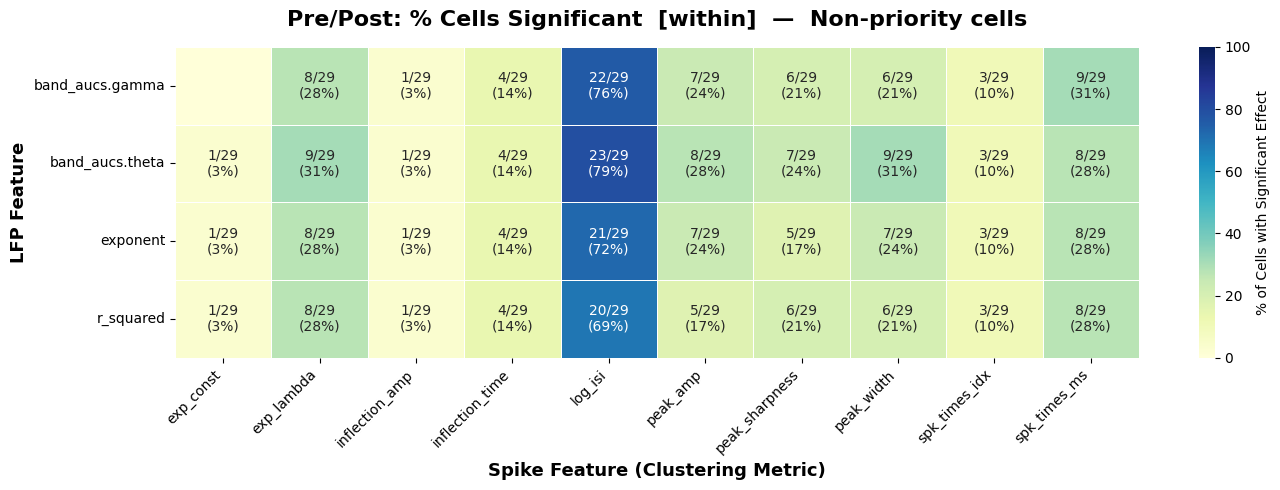

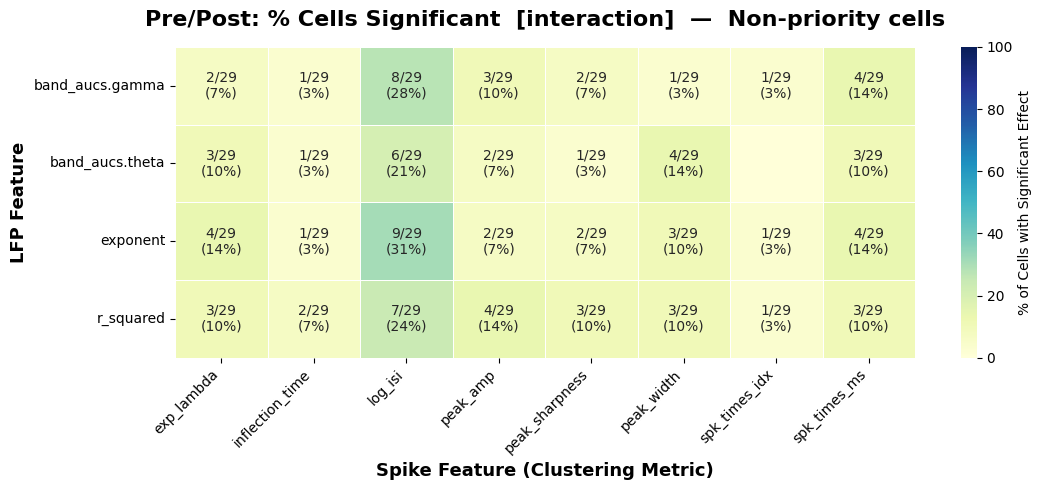


All cells combined (n=43)


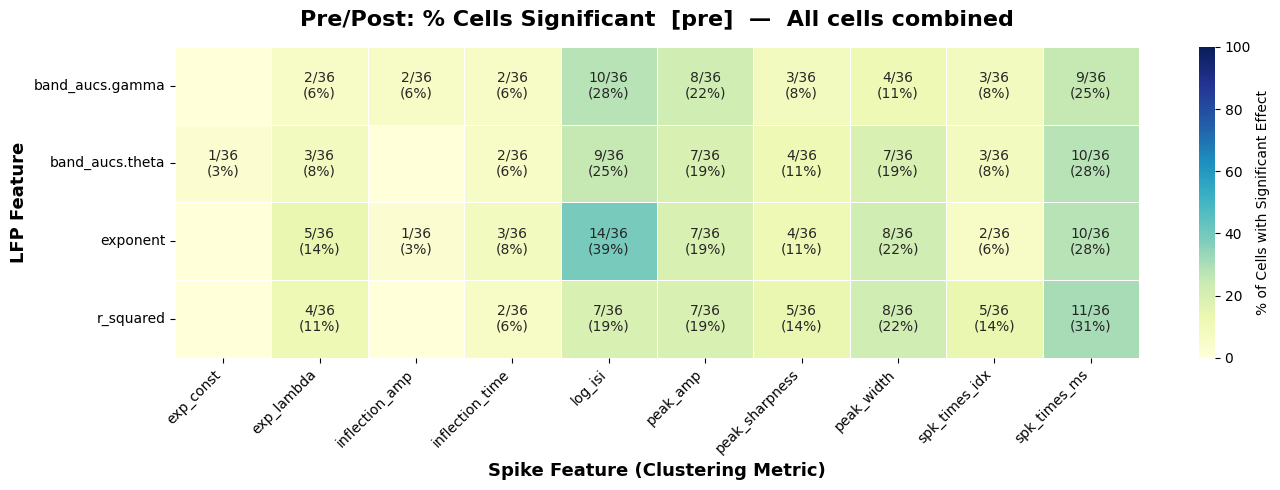

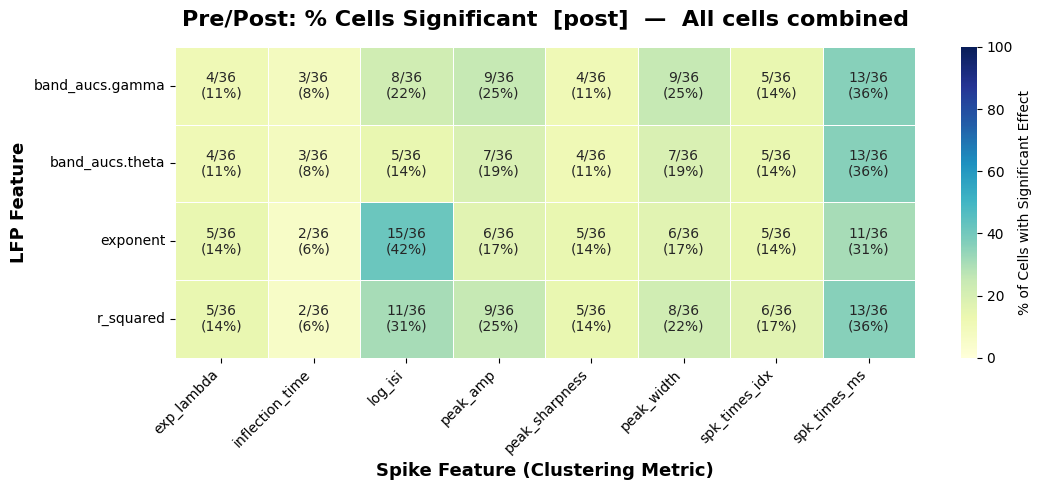

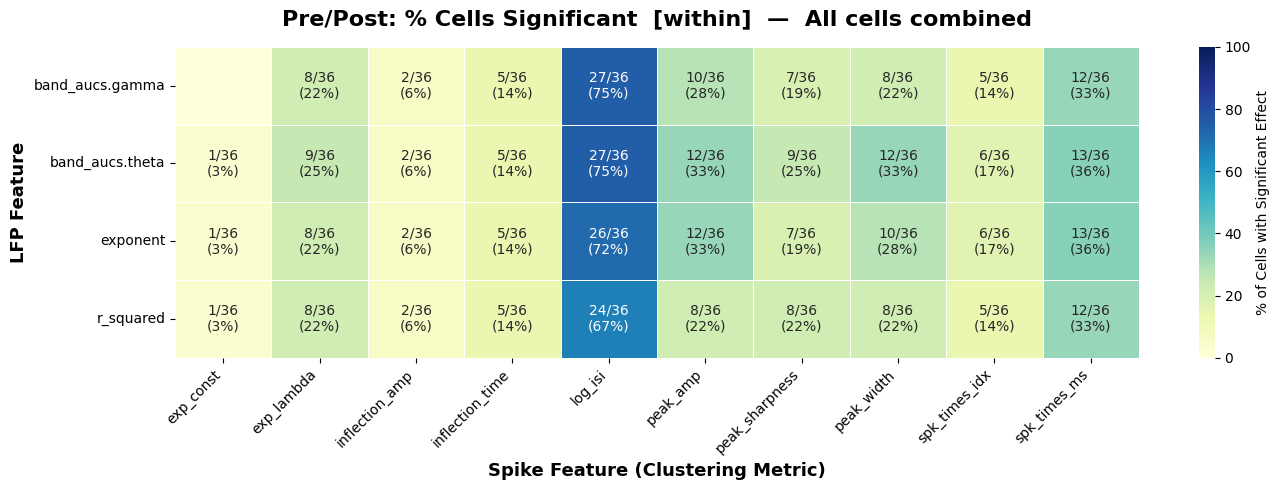

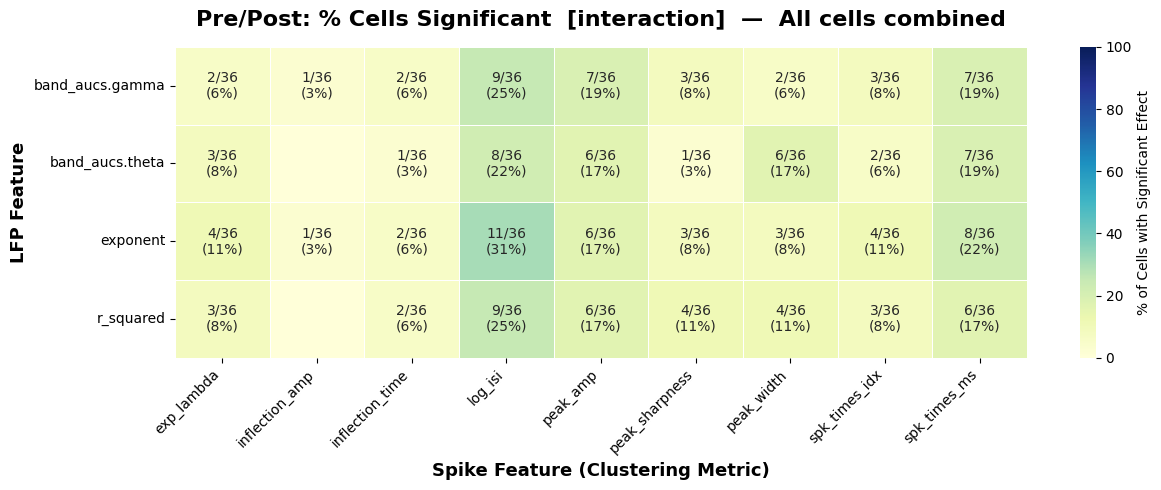

In [8]:
for label, cell_ids in SUBSET_LABELS:
    print(f"\n{'='*60}\n{label} (n={len(cell_ids)})\n{'='*60}")
    df_sub = df_reduced[df_reduced["cell_id"].isin(cell_ids)]
    plot_prepost_yield(df_sub, subset_label=label)

> High yield (>30%) means the effect is consistent across the population, not driven by a few cells. Low yield with large effect size means the effect exists strongly in some cells but not others — possibly a cell-type effect worth investigating in the metadata notebook.

## Priority vs non-priority cells

Priority cells were selected because they have the biggest waveform differences between clusters and low temporal drift — they are the cleanest cases. Do they show stronger pre/post LFP effects?

**Stats**: Mann-Whitney U + BH-FDR. When group sizes are unbalanced (>3:1), we subsample the larger group before testing. **Right panel**: median difference (Priority − NP) with 95% bootstrap CI (n=2000).

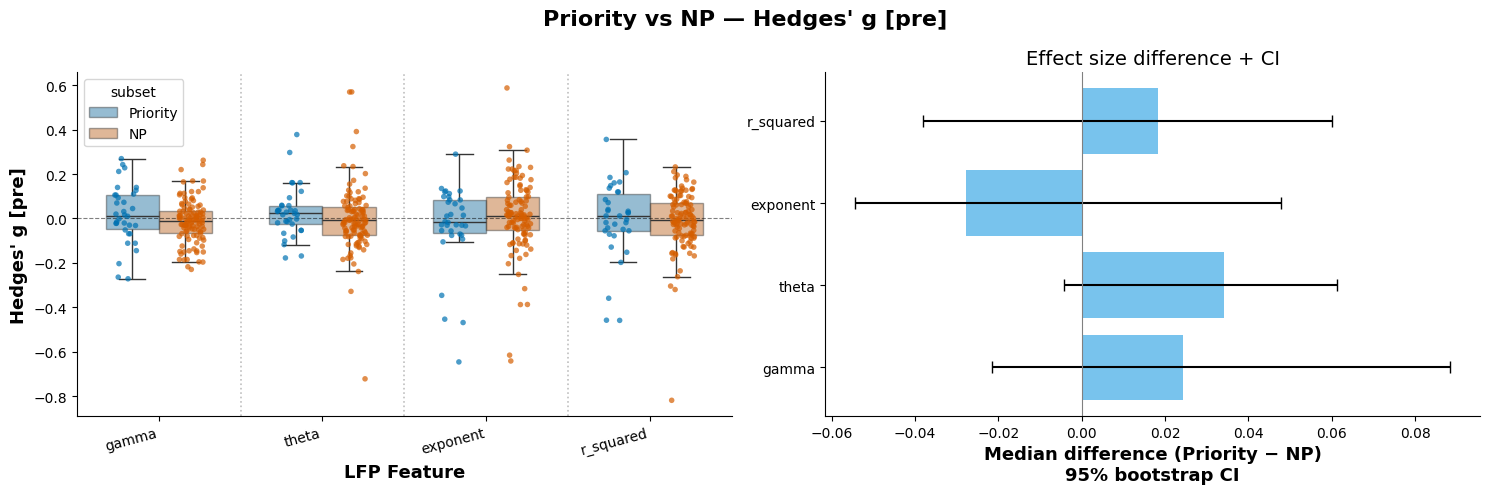

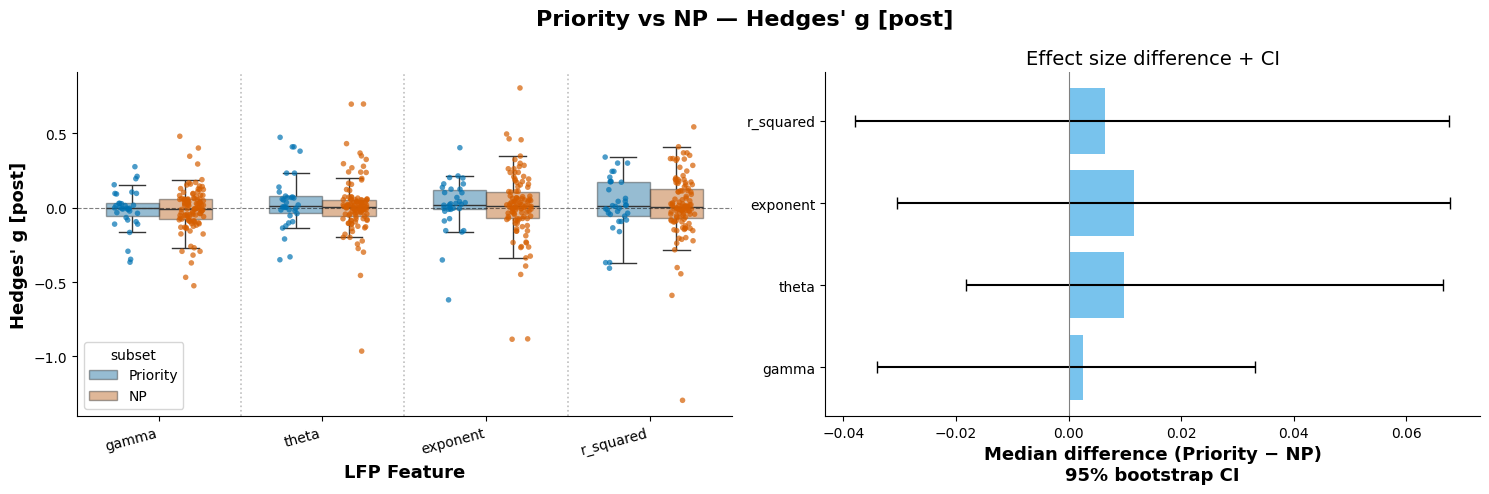

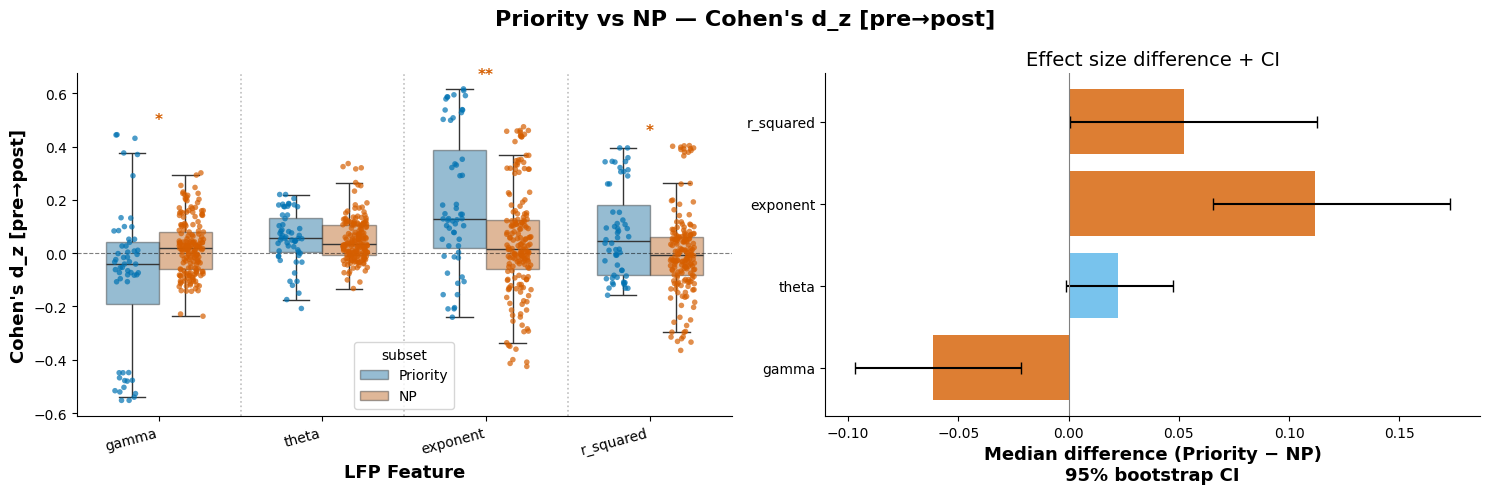

In [9]:
plot_prepost_priority_vs_np(df_reduced, subsets,
                             lfp_features=LFP_NUMERICAL)

> If priority cells show significantly stronger effects, it suggests that larger waveform differences between clusters go hand-in-hand with stronger LFP coupling — biologically meaningful. If there's no difference, the LFP effect is equally present regardless of how distinct the spike waveform clusters are.